In [1]:
# ============================================================
# 021_build_paper_graph
# ============================================================
#
# Overview
# ----------------
# This notebook constructs a citation graph from an accumulated research corpus
# and transforms it into a navigable, analysis-ready network representation.
#
# The primary objectives are to:
#  - Reveal the structural organization of the literature via citation links
#  - Identify core, peripheral, and bridging papers
#  - Detect thematic communities (clusters) within the research landscape
#  - Compute centrality metrics to surface influential and anchoring papers
#
# The resulting graph is designed to serve as a core component of a
# PhD-style research agent workflow, supporting weekly updates, longitudinal
# monitoring of the field, and systematic discovery of intellectual structure
# and underexplored research gaps.
#
#
# Inputs / Outputs
# ----------------
# Inputs:
#  - Accumulated paper metadata and artifacts from prior discovery steps
#    (e.g., OpenAlex IDs, DOIs, titles, years, citation relations)
#  - Cached OpenAlex work records for reference resolution (optional)
#
# Outputs:
#  - nodes.csv:
#       Canonical paper-level nodes with unified paper_uid and metadata
#  - edges.csv:
#       Directed citation edges (source -> target)
#  - nodes_with_community.csv:
#       Nodes annotated with community (cluster) assignments
#  - nodes_with_metrics.csv:
#       Nodes enriched with centrality metrics (PageRank, degree, etc.)
#  - community_summary.csv:
#       Cluster-level summaries and representative papers
#  - nodes_viz.csv / edges_viz.csv:
#       Visualization-ready exports for Gephi, Cytoscape, D3, Neo4j
#  - graph.gexf (optional):
#       Interactive graph export for Gephi-based exploration
#
#
# Structure
# ----------------
# 1. Configuration and environment setup
# 2. Load accumulated paper corpus and citation data
# 3. Normalize identifiers and merge duplicate records
# 4. Construct node and edge tables for the citation graph
# 5. Build the citation graph (directed) and compute basic statistics
# 6. Detect communities (clusters) within the graph
# 7. Compute centrality metrics (e.g., PageRank, degree)
# 8. Summarize important clusters and representative papers
# 9. Export graph artifacts for downstream analysis and visualization
# 10. Generate RQ × Community reading maps and gap-oriented review outputs
#
#
# Notes
# ----------------
# - A stable, unified paper_uid is critical for consistency across Notion,
#   Drive, and downstream notebooks (e.g., gap analysis, RQ updates).
# - Community detection and centrality metrics are heuristic and intended
#   as navigational aids, not definitive measures of importance.
# - For visualization, subgraphs (e.g., largest connected component or
#   top-ranked papers) are often more interpretable than the full graph.
# - Section 10 translates graph structure into human-actionable reading
#   guidance (what to read first, what bridges clusters, and where gaps exist),
#   closing the loop between automated analysis and researcher decision-making.
# - This notebook is intended to be run periodically (e.g., weekly),
#   with human-in-the-loop review of clusters, core papers, and emerging gaps.


In [2]:
# ============================================================
# 1. Configuration and environment setup
# ============================================================
#
# Purpose:
# - Centralize parameters (scope, thresholds, output paths)
# - Initialize run-specific artifact directory (timestamped)
# - Prepare lightweight logging utilities
# - Keep secrets in env vars (never hard-code)
#

from __future__ import annotations

import os
import re
import json
import hashlib
import datetime as dt
from dataclasses import dataclass, asdict
from typing import Any, Dict, Optional, Tuple

import numpy as np
import pandas as pd

# ----------------
# Reproducibility
# ----------------
SEED = 42
np.random.seed(SEED)

# ----------------
# Run identifier (timestamped)
# ----------------
RUN_ID = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

# ----------------
# Project paths
# ----------------
PROJECT_ROOT = os.getcwd()
CACHE_DIR = os.path.join(PROJECT_ROOT, "cache")

# Timestamped artifacts directory (recommended for reproducibility)
ARTIFACTS_DIR = os.path.join(
    PROJECT_ROOT,
    "artifacts",
    f"day21_paper_graph_{RUN_ID}"
)

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ----------------
# Core configuration
# ----------------
@dataclass(frozen=True)
class Config:
    # Scope
    graph_scope: str = "all"            # "all" | "recent" | "rq_high_only"
    min_year: int = 2000                # filter papers earlier than this year (if applicable)
    max_nodes: int = 50_000             # safety cap for graph building

    # Edge construction
    edge_type: str = "references"       # citation edges as directed source->target
    include_external_nodes: bool = True # keep targets outside corpus as external nodes

    # Dedup / ID normalization
    dedup_strict: bool = True
    paper_id_prefix_openalex: str = "OA:"
    paper_id_prefix_doi: str = "DOI:"
    paper_id_prefix_arxiv: str = "ARXIV:"
    paper_id_prefix_titlehash: str = "TITLE:"

    # Clustering / centrality
    community_method: str = "louvain"   # "louvain" | "leiden" (if available)
    centrality_methods: Tuple[str, ...] = ("pagerank", "in_degree", "out_degree")

    # I/O
    project_root: str = PROJECT_ROOT
    cache_dir: str = CACHE_DIR
    artifacts_dir: str = ARTIFACTS_DIR
    run_id: str = RUN_ID

    # Integrations (optional)
    notion_db_id: str = os.getenv("NOTION_DB_ID", "")
    notion_token: str = os.getenv("NOTION_TOKEN", "")
    openalex_email: str = os.getenv("OPENALEX_EMAIL", "")  # recommended by OpenAlex

CFG = Config()
CFG_DICT = asdict(CFG)

print("Loaded Config:")
print(json.dumps(CFG_DICT, indent=2, ensure_ascii=False))

# ----------------
# Structured run logging (JSONL)
# ----------------
RUNLOG_PATH = os.path.join(CFG.artifacts_dir, f"runlog_{CFG.run_id}.jsonl")

def log_event(step: str, status: str, payload: Optional[Dict[str, Any]] = None) -> None:
    """Append a single structured log line (JSONL)."""
    rec = {
        "ts": dt.datetime.now().isoformat(),
        "run_id": CFG.run_id,
        "step": step,
        "status": status,
        "payload": payload or {},
    }
    with open(RUNLOG_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

log_event("config", "ok", {"artifacts_dir": CFG.artifacts_dir, "cache_dir": CFG.cache_dir})

# ----------------
# Helpers: string normalization + stable hashing (for titlehash IDs)
# ----------------
_ws_re = re.compile(r"\s+")

def normalize_text(s: str) -> str:
    s = (s or "").strip().lower()
    s = _ws_re.sub(" ", s)
    return s

def stable_hash(s: str, n: int = 12) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()[:n]

print(f"Run ID       : {CFG.run_id}")
print(f"Artifacts dir: {CFG.artifacts_dir}")
print(f"Runlog path  : {RUNLOG_PATH}")


Loaded Config:
{
  "graph_scope": "all",
  "min_year": 2000,
  "max_nodes": 50000,
  "edge_type": "references",
  "include_external_nodes": true,
  "dedup_strict": true,
  "paper_id_prefix_openalex": "OA:",
  "paper_id_prefix_doi": "DOI:",
  "paper_id_prefix_arxiv": "ARXIV:",
  "paper_id_prefix_titlehash": "TITLE:",
  "community_method": "louvain",
  "centrality_methods": [
    "pagerank",
    "in_degree",
    "out_degree"
  ],
  "project_root": "/Users/yuetoya/Desktop/researchOS100-private/notebooks",
  "cache_dir": "/Users/yuetoya/Desktop/researchOS100-private/notebooks/cache",
  "artifacts_dir": "/Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608",
  "run_id": "20260114_094608",
  "notion_db_id": "",
  "notion_token": "",
  "openalex_email": ""
}
Run ID       : 20260114_094608
Artifacts dir: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608
Runlog path  : /Users/yuetoya/Desktop/researchO

In [3]:
# ============================================================
# 2. Load accumulated paper corpus and citation data
# ============================================================
#
# Goal:
# - Resolve the latest Day20 run folder under ./artifacts/day20/YYYYMMDD_HHMMSS
# - Load accumulated paper metadata (core + enriched backfill pool)
# - Load cached OpenAlex Work JSON (openalex_work_cache.json)
# - Extract citation edges from cache via referenced_works (when present)
#
# Outputs (in-memory):
# - corpus_df: unified paper metadata table (deduped)
# - work_cache: dict[str, dict]  (WID -> OpenAlex Work JSON)
# - edges_from_cache_df: citation edges derived from referenced_works
#

from pathlib import Path
import re
import json
import numpy as np
import pandas as pd

# ----------------
# Resolve latest Day20 run folder (relative to current notebook directory)
# ----------------
NOTEBOOK_ROOT = Path.cwd()
DAY20_ROOT = NOTEBOOK_ROOT / "artifacts" / "day20"

def _is_run_dir(p: Path) -> bool:
    return p.is_dir() and re.fullmatch(r"\d{8}_\d{6}", p.name) is not None

def find_latest_run_dir(root: Path) -> Path:
    if not root.exists():
        raise FileNotFoundError(f"DAY20_ROOT not found: {root}")
    run_dirs = [p for p in root.iterdir() if _is_run_dir(p)]
    if not run_dirs:
        raise FileNotFoundError(
            f"No Day20 run folders found under: {root} (expected YYYYMMDD_HHMMSS)"
        )
    return sorted(run_dirs, key=lambda p: p.name)[-1]

DAY20_RUN_DIR = find_latest_run_dir(DAY20_ROOT)
print(f"Latest Day20 run dir: {DAY20_RUN_DIR.relative_to(NOTEBOOK_ROOT)}")

# Optional: quick file listing (top-level)
files_df = pd.DataFrame(
    [{"name": p.name, "ext": p.suffix.lower(), "path": str(p.relative_to(NOTEBOOK_ROOT))}
     for p in sorted(DAY20_RUN_DIR.glob("*")) if p.is_file()]
).sort_values(["ext", "name"]).reset_index(drop=True)
display(files_df)

log_event("resolve_day20_run_dir", "ok", {"day20_run_dir": str(DAY20_RUN_DIR)})

# ----------------
# Helper functions (robust to NaNs)
# ----------------
def to_str_or_none(x):
    if x is None:
        return None
    if isinstance(x, float) and np.isnan(x):
        return None
    s = str(x).strip()
    return s if s and s.lower() != "nan" else None

def extract_wid_from_openalex_id(openalex_id: str):
    """
    Input:  https://openalex.org/W2050766092
    Return: W2050766092
    """
    s = to_str_or_none(openalex_id)
    if not s:
        return None
    if "/W" in s:
        return "W" + s.split("/W")[-1]
    if s.startswith("W"):
        return s
    return None

def normalize_doi(doi: str):
    s = to_str_or_none(doi)
    if not s:
        return None
    s = s.lower().strip()
    s = s.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return s

_ws_re = re.compile(r"\s+")
def normalize_text(s: str) -> str:
    s = (s or "").strip().lower()
    s = _ws_re.sub(" ", s)
    return s

def ensure_columns(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for c in cols:
        if c not in df.columns:
            df[c] = np.nan
    return df

# ----------------
# Load Day20 artifacts (from latest run dir)
# ----------------
paths = {
    "core": DAY20_RUN_DIR / "day20_core_papers.csv",
    "ranked": DAY20_RUN_DIR / "backfill_ranked.csv",
    "top200": DAY20_RUN_DIR / "backfill_top200.csv",
    "queue200": DAY20_RUN_DIR / "backfill_fetch_queue_top200.csv",
    "work_cache": DAY20_RUN_DIR / "openalex_work_cache.json",
}

for k, p in paths.items():
    print(f"{k:10s} -> exists={p.exists()}  path={p.relative_to(NOTEBOOK_ROOT)}")

core_df = pd.read_csv(paths["core"]) if paths["core"].exists() else pd.DataFrame()
ranked_df = pd.read_csv(paths["ranked"]) if paths["ranked"].exists() else pd.DataFrame()
top200_df = pd.read_csv(paths["top200"]) if paths["top200"].exists() else pd.DataFrame()
queue200_df = pd.read_csv(paths["queue200"]) if paths["queue200"].exists() else pd.DataFrame()

print("\nLoaded shapes:")
print(" core_df     :", core_df.shape)
print(" ranked_df   :", ranked_df.shape)
print(" top200_df   :", top200_df.shape)
print(" queue200_df :", queue200_df.shape)

log_event("load_day20_tables", "ok", {
    "core_rows": int(core_df.shape[0]),
    "ranked_rows": int(ranked_df.shape[0]),
    "top200_rows": int(top200_df.shape[0]),
    "queue200_rows": int(queue200_df.shape[0]),
})

# ----------------
# Unify paper metadata into a single corpus_df
#   - ranked_df: broad enriched pool (best base)
#   - core_df  : adds notion_page_id and any existing corpus metadata
# ----------------
STD_COLS = [
    "openalex_id", "openalex_wid", "doi", "title",
    "publication_year", "publication_date",
    "cited_by_count", "abstract",
    "oa_status", "oa_url", "venue", "type",
    "rq_score", "priority_score",
    "min_hop", "source_cores",
    "notion_page_id", "notion_page_url",
]

ranked_df = ensure_columns(ranked_df, STD_COLS)
core_df = ensure_columns(core_df, STD_COLS)

# core_df schema often uses "year" instead of "publication_year"
if not core_df.empty and "year" in core_df.columns:
    core_df["publication_year"] = core_df["publication_year"].fillna(core_df["year"])

# Clean / derive IDs
for df in [ranked_df, core_df]:
    df["openalex_id"] = df["openalex_id"].apply(to_str_or_none)
    df["openalex_wid"] = df["openalex_wid"].apply(to_str_or_none)
    df["openalex_wid"] = df.apply(
        lambda r: r["openalex_wid"] if r["openalex_wid"] else extract_wid_from_openalex_id(r["openalex_id"]),
        axis=1,
    )

    df["doi"] = df["doi"].apply(to_str_or_none)
    df["doi_norm"] = df["doi"].apply(normalize_doi)

    df["title"] = df["title"].apply(to_str_or_none)
    df["title_norm"] = df["title"].apply(lambda s: normalize_text(s or ""))

# Combine and dedupe (keep richer row)
combined = pd.concat(
    [ranked_df[STD_COLS + ["doi_norm", "title_norm"]], core_df[STD_COLS + ["doi_norm", "title_norm"]]],
    ignore_index=True
)

def richness_score(row) -> int:
    keys = ["abstract", "venue", "oa_url", "rq_score", "priority_score", "notion_page_id"]
    return sum(1 for k in keys if to_str_or_none(row.get(k)) is not None)

combined["_rich"] = combined.apply(richness_score, axis=1)

# Dedupe key preference: openalex_wid > doi_norm > title_norm
combined["dedupe_key"] = combined.apply(
    lambda r: to_str_or_none(r["openalex_wid"])
              or (f"DOI:{to_str_or_none(r['doi_norm'])}" if to_str_or_none(r["doi_norm"]) else None)
              or (f"TITLE:{to_str_or_none(r['title_norm'])}" if to_str_or_none(r["title_norm"]) else None),
    axis=1
)

combined = combined.sort_values("_rich", ascending=False).drop_duplicates("dedupe_key").reset_index(drop=True)

corpus_df = combined.drop(columns=["_rich"]).copy()

print("\nUnified corpus_df:")
print(" shape  :", corpus_df.shape)
print(" sample :", corpus_df[["openalex_wid", "doi_norm", "title"]].head(5).to_dict("records"))
display(corpus_df.head(10))

log_event("build_corpus_df", "ok", {"corpus_rows": int(corpus_df.shape[0])})

# ----------------
# Load OpenAlex work cache (WID -> Work JSON)
# ----------------
work_cache: dict[str, dict] = {}
if paths["work_cache"].exists():
    with open(paths["work_cache"], "r", encoding="utf-8") as f:
        work_cache = json.load(f)

print("\nOpenAlex work cache:")
print(" WIDs cached:", len(work_cache))

log_event("load_openalex_cache", "ok", {"n_cached_works": len(work_cache)})

# ----------------
# Extract citation edges from cache via referenced_works (references)
# ----------------
rows = []
works_with_refs = 0
works_missing_refs = 0

for wid, work in work_cache.items():
    src_id = to_str_or_none(work.get("id")) or (f"https://openalex.org/{wid}" if wid else None)
    refs = work.get("referenced_works")
    if not refs:
        works_missing_refs += 1
        continue

    works_with_refs += 1
    for tgt in refs:
        tgt_id = to_str_or_none(tgt)
        if src_id and tgt_id:
            rows.append({"source_openalex_id": src_id, "target_openalex_id": tgt_id})

edges_from_cache_df = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

print("\nEdges extracted from cache (references):")
print(" works_with_refs    :", works_with_refs)
print(" works_missing_refs :", works_missing_refs)
print(" edges              :", edges_from_cache_df.shape)

display(edges_from_cache_df.head(10))

log_event("extract_edges_from_cache", "ok", {
    "works_with_refs": works_with_refs,
    "works_missing_refs": works_missing_refs,
    "edges": int(edges_from_cache_df.shape[0]),
})

# ----------------
# Optional: restrict corpus to top200 for faster iteration (debug)
# ----------------
DEBUG_RESTRICT_TO_TOP200 = False
if DEBUG_RESTRICT_TO_TOP200 and not top200_df.empty:
    top_wids = set(top200_df["openalex_wid"].apply(to_str_or_none).dropna().tolist())
    before = corpus_df.shape[0]
    corpus_df = corpus_df[corpus_df["openalex_wid"].isin(top_wids)].reset_index(drop=True)
    after = corpus_df.shape[0]
    print(f"\n[DEBUG] Restricted corpus_df to top200: {before} -> {after}")
    log_event("debug_restrict_top200", "ok", {"before": before, "after": after})


Latest Day20 run dir: artifacts/day20/20260113_061442


,name,ext,path
0,backfill_fetch_queue_top200.csv,.csv,artifacts/day20/20260113_061442/backfill_fetch...
1,backfill_ranked.csv,.csv,artifacts/day20/20260113_061442/backfill_ranke...
2,backfill_top200.csv,.csv,artifacts/day20/20260113_061442/backfill_top20...
3,candidate_pool_enriched.csv,.csv,artifacts/day20/20260113_061442/candidate_pool...
4,candidate_pool_enriched_deduped.csv,.csv,artifacts/day20/20260113_061442/candidate_pool...
5,candidate_pool_enriched_scored.csv,.csv,artifacts/day20/20260113_061442/candidate_pool...
6,candidate_pool_raw.csv,.csv,artifacts/day20/20260113_061442/candidate_pool...
7,core_openalex_resolved.csv,.csv,artifacts/day20/20260113_061442/core_openalex_...
8,corpus_rq_scores.csv,.csv,artifacts/day20/20260113_061442/corpus_rq_scor...
9,corpus_with_rq_scores.csv,.csv,artifacts/day20/20260113_061442/corpus_with_rq...


core       -> exists=True  path=artifacts/day20/20260113_061442/day20_core_papers.csv
ranked     -> exists=True  path=artifacts/day20/20260113_061442/backfill_ranked.csv
top200     -> exists=True  path=artifacts/day20/20260113_061442/backfill_top200.csv
queue200   -> exists=True  path=artifacts/day20/20260113_061442/backfill_fetch_queue_top200.csv
work_cache -> exists=True  path=artifacts/day20/20260113_061442/openalex_work_cache.json

Loaded shapes:
 core_df     : (30, 20)
 ranked_df   : (902, 29)
 top200_df   : (200, 29)
 queue200_df : (200, 11)

Unified corpus_df:
 shape  : (932, 21)
 sample : [{'openalex_wid': 'W2055251470', 'doi_norm': '10.1111/j.1468-2370.2005.00113.x', 'title': 'International venture capital research: From cross‐country comparisons to crossing borders'}, {'openalex_wid': 'W4256499879', 'doi_norm': '10.1093/rfs/hhn014', 'title': 'The Performance of Private Equity Funds'}, {'openalex_wid': 'W2023066798', 'doi_norm': '10.2307/3069378', 'title': 'STRUCTURAL INERTIA,

,openalex_id,openalex_wid,doi,title,publication_year,publication_date,cited_by_count,abstract,oa_status,oa_url,...,type,rq_score,priority_score,min_hop,source_cores,notion_page_id,notion_page_url,doi_norm,title_norm,dedupe_key
0,https://openalex.org/W2055251470,W2055251470,10.1111/j.1468-2370.2005.00113.x,International venture capital research: From c...,2005.0,2005-09-01,272,Venture capital (VC) has become an internation...,closed,https://doi.org/10.1111/j.1468-2370.2005.00113.x,...,article,0.042308,0.236104,1.0,W2942425576,NaN,NaN,10.1111/j.1468-2370.2005.00113.x,international venture capital research: from c...,W2055251470
1,https://openalex.org/W4256499879,W4256499879,10.1093/rfs/hhn014,The Performance of Private Equity Funds,2008.0,2008-03-19,556,The performance of private equity funds as rep...,closed,https://doi.org/10.1093/rfs/hhn014,...,article,0.007692,0.219067,1.0,W3122536485,NaN,NaN,10.1093/rfs/hhn014,the performance of private equity funds,W4256499879
2,https://openalex.org/W2023066798,W2023066798,10.2307/3069378,"STRUCTURAL INERTIA, IMITATION, AND FOREIGN EXP...",2002.0,2002-06-01,392,The foreign expansion of firms is healed as an...,closed,https://doi.org/10.2307/3069378,...,article,0.007692,0.220716,1.0,W2119345321,NaN,NaN,10.2307/3069378,"structural inertia, imitation, and foreign exp...",W2023066798
3,https://openalex.org/W2153355385,W2153355385,10.1177/0149206311429614,Insights and New Directions from Demand-Side A...,2011.0,2011-12-16,373,The authors review the progress of three rapid...,closed,https://doi.org/10.1177/0149206311429614,...,article,0.026923,0.219981,1.0,W4387937766,NaN,NaN,10.1177/0149206311429614,insights and new directions from demand-side a...,W2153355385
4,https://openalex.org/W1981631194,W1981631194,10.3389/fpls.2014.00462,Control of arbuscular mycorrhiza development b...,2014.0,2014-09-11,76,"OPINION article Front. Plant Sci., 11 Septembe...",gold,https://www.frontiersin.org/articles/10.3389/f...,...,article,0.003846,0.133708,1.0,W4408694264,NaN,NaN,10.3389/fpls.2014.00462,control of arbuscular mycorrhiza development b...,W1981631194
5,https://openalex.org/W1996751723,W1996751723,10.1002/gsj.1030,The global strategy of emerging multinationals...,2012.0,2012-05-01,440,Abstract The global strategy of multinational ...,closed,https://doi.org/10.1002/gsj.1030,...,article,0.023077,0.219614,1.0,W2942425576,NaN,NaN,10.1002/gsj.1030,the global strategy of emerging multinationals...,W1996751723
6,https://openalex.org/W2015031445,W2015031445,10.1111/j.1540-6520.2010.00425.x,Entrepreneurship as Method: Open Questions for...,2011.0,2011-01-01,592,"In this essay, we outline the provocative argu...",closed,https://doi.org/10.1111/j.1540-6520.2010.00425.x,...,article,0.011538,0.219392,1.0,W4387937766,NaN,NaN,10.1111/j.1540-6520.2010.00425.x,entrepreneurship as method: open questions for...,W2015031445
7,https://openalex.org/W2029453648,W2029453648,10.1504/ijesb.2013.050750,Gender differences in business success of Germ...,2012.0,2012-12-02,56,Many studies found that women-owned firms unde...,closed,https://doi.org/10.1504/ijesb.2013.050750,...,article,0.007692,0.133807,1.0,W4400652554,NaN,NaN,10.1504/ijesb.2013.050750,gender differences in business success of germ...,W2029453648
8,https://openalex.org/W604374759,W604374759,10.5860/choice.51-0969,"Worthless, impossible, and stupid: how contrar...",2013.0,2013-09-19,60,Introducing the global mind-set changing the w...,closed,https://doi.org/10.5860/choice.51-0969,...,article,0.007692,0.133857,1.0,W2186324016,NaN,NaN,10.5860/choice.51-0969,"worthless, impossible, and stupid: how contrar...",W604374759
9,https://openalex.org/W4392009997,W4392009997,10.30574/wjarr.2024.21.2.0557,Implementing health and safety standards in Of...,2024.0,2024-02-21,40,Offshore wind farms represent a significant so...,hybrid,https://wjarr.com/sites/default/files/WJARR-20...,...,article,0.023077,0.133362,1.0,W4394018401,NaN,NaN,10.30574/wjarr.2024.21.2.0557,implementing health 


OpenAlex work cache:
 WIDs cached: 983

Edges extracted from cache (references):
 works_with_refs    : 810
 works_missing_refs : 173
 edges              : (48924, 2)


,source_openalex_id,target_openalex_id
0,https://openalex.org/W109618454,https://openalex.org/W2038505981
1,https://openalex.org/W109618454,https://openalex.org/W1976863731
2,https://openalex.org/W109618454,https://openalex.org/W2094204367
3,https://openalex.org/W109618454,https://openalex.org/W3125987296
4,https://openalex.org/W109618454,https://openalex.org/W2072683182
5,https://openalex.org/W109618454,https://openalex.org/W2057307297
6,https://openalex.org/W109618454,https://openalex.org/W3123637450
7,https://openalex.org/W109618454,https://openalex.org/W3125935778
8,https://openalex.org/W109618454,https://openalex.org/W3121759882
9,https://openalex.org/W109618454,https://openalex.org/W1997246417


In [4]:
# ============================================================
# 3. Normalize identifiers and merge duplicate records (SAFE / single-pass)
# ============================================================
#
# Goal:
# - Create canonical paper_uid for each paper (OA > DOI > TITLE hash)
# - Build ID mappings (openalex_id/wid/doi_norm -> paper_uid)
# - Convert OpenAlex-ID-based edges into paper_uid-based edges
# - If CFG.include_external_nodes=True, assign stable EXT:Wxxxx IDs to external targets
#

import re
import hashlib
import numpy as np
import pandas as pd

# ----------------
# Helpers
# ----------------
def stable_hash(s: str, n: int = 12) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()[:n]

def build_paper_uid(row) -> str:
    wid = to_str_or_none(row.get("openalex_wid"))
    if wid:
        return f"{CFG.paper_id_prefix_openalex}{wid}"

    doi_norm = to_str_or_none(row.get("doi_norm"))
    if doi_norm:
        return f"{CFG.paper_id_prefix_doi}{doi_norm}"

    title_norm = to_str_or_none(row.get("title_norm"))
    if title_norm:
        return f"{CFG.paper_id_prefix_titlehash}{stable_hash(title_norm)}"

    return f"{CFG.paper_id_prefix_titlehash}{stable_hash('missing')}"

def make_external_uid_from_openalex_id(openalex_id: str) -> str | None:
    oid = to_str_or_none(openalex_id)
    if not oid:
        return None
    wid = extract_wid_from_openalex_id(oid)
    return f"EXT:{wid}" if wid else None

# ----------------
# 1) Create paper_uid for corpus_df
# ----------------
corpus_df["paper_uid"] = corpus_df.apply(build_paper_uid, axis=1)

# ----------------
# 2) Build mapping tables
# ----------------
# NOTE: use "dropna" but also guard against string "nan"
openalex_id_to_uid = {}
openalex_wid_to_uid = {}
doi_to_uid = {}

for _, r in corpus_df.iterrows():
    uid = r["paper_uid"]

    oa_id = to_str_or_none(r.get("openalex_id"))
    if oa_id:
        openalex_id_to_uid[oa_id] = uid

    wid = to_str_or_none(r.get("openalex_wid"))
    if wid:
        openalex_wid_to_uid[wid] = uid

    doi_norm = to_str_or_none(r.get("doi_norm"))
    if doi_norm:
        doi_to_uid[doi_norm] = uid

print("ID mappings built:")
print(" openalex_id_to_uid:", len(openalex_id_to_uid))
print(" openalex_wid_to_uid:", len(openalex_wid_to_uid))
print(" doi_to_uid:", len(doi_to_uid))

log_event("build_id_maps", "ok", {
    "openalex_id_to_uid": len(openalex_id_to_uid),
    "openalex_wid_to_uid": len(openalex_wid_to_uid),
    "doi_to_uid": len(doi_to_uid),
})

def map_openalex_id_to_uid(openalex_id: str) -> str | None:
    oid = to_str_or_none(openalex_id)
    if not oid:
        return None
    if oid in openalex_id_to_uid:
        return openalex_id_to_uid[oid]
    wid = extract_wid_from_openalex_id(oid)
    if wid and wid in openalex_wid_to_uid:
        return openalex_wid_to_uid[wid]
    return None

# ----------------
# 3) Build edges_uid_df (single-pass, robust)
# ----------------
tmp = edges_from_cache_df.copy()

tmp["source_uid"] = tmp["source_openalex_id"].apply(map_openalex_id_to_uid)
tmp["target_uid"] = tmp["target_openalex_id"].apply(map_openalex_id_to_uid)

# Keep edges with known sources (we only trust outgoing edges from cached works)
before = tmp.shape[0]
tmp = tmp[tmp["source_uid"].notna()].copy()
after = tmp.shape[0]
print(f"Kept edges with known sources: {before} -> {after}")

if CFG.include_external_nodes:
    # External targets -> EXT:Wxxxx
    mask_ext = tmp["target_uid"].isna()
    tmp.loc[mask_ext, "target_uid"] = tmp.loc[mask_ext, "target_openalex_id"].apply(make_external_uid_from_openalex_id)

    # Drop still-missing targets (rare: non-standard OpenAlex IDs)
    tmp = tmp[tmp["target_uid"].notna()].copy()

    tmp["target_is_external"] = tmp["target_uid"].astype(str).str.startswith("EXT:")
else:
    # Internal-only edges: drop edges with unknown targets
    tmp = tmp[tmp["target_uid"].notna()].copy()
    tmp["target_is_external"] = False

# Remove self-loops
tmp = tmp[tmp["source_uid"] != tmp["target_uid"]].copy()

edges_uid_df = tmp[["source_uid", "target_uid", "target_is_external"]].drop_duplicates().reset_index(drop=True)

print("\nUID-based edges:")
print(" edges:", edges_uid_df.shape)
print(" external targets:", int(edges_uid_df["target_is_external"].sum()))
display(edges_uid_df.head(10))

log_event("build_edges_uid", "ok", {
    "edges_uid": int(edges_uid_df.shape[0]),
    "external_targets": int(edges_uid_df["target_is_external"].sum()),
    "include_external_nodes": bool(CFG.include_external_nodes),
})

# ----------------
# 4) Build nodes_df (internal corpus only; external nodes can be added later in #4)
# ----------------
nodes_df = corpus_df.copy()

# Ensure these columns exist (avoid KeyError if some are missing)
for c in ["notion_page_id", "notion_page_url", "priority_score"]:
    if c not in nodes_df.columns:
        nodes_df[c] = np.nan

nodes_df = nodes_df[[
    "paper_uid", "openalex_id", "openalex_wid", "doi", "doi_norm",
    "title", "publication_year", "publication_date", "venue", "type",
    "cited_by_count", "rq_score", "priority_score",
    "notion_page_id", "notion_page_url",
]].copy()

nodes_df = nodes_df.drop_duplicates("paper_uid").reset_index(drop=True)

print("\nNodes table:")
print(" nodes:", nodes_df.shape)
display(nodes_df.head(10))

log_event("build_nodes_df", "ok", {"nodes": int(nodes_df.shape[0])})


ID mappings built:
 openalex_id_to_uid: 902
 openalex_wid_to_uid: 902
 doi_to_uid: 901
Kept edges with known sources: 48924 -> 47600

UID-based edges:
 edges: (47594, 3)
 external targets: 44821


,source_uid,target_uid,target_is_external
0,OA:W109618454,EXT:W2038505981,True
1,OA:W109618454,EXT:W1976863731,True
2,OA:W109618454,EXT:W2094204367,True
3,OA:W109618454,EXT:W3125987296,True
4,OA:W109618454,EXT:W2072683182,True
5,OA:W109618454,EXT:W2057307297,True
6,OA:W109618454,EXT:W3123637450,True
7,OA:W109618454,EXT:W3125935778,True
8,OA:W109618454,OA:W3121759882,False
9,OA:W109618454,EXT:W1997246417,True



Nodes table:
 nodes: (932, 15)


,paper_uid,openalex_id,openalex_wid,doi,doi_norm,title,publication_year,publication_date,venue,type,cited_by_count,rq_score,priority_score,notion_page_id,notion_page_url
0,OA:W2055251470,https://openalex.org/W2055251470,W2055251470,10.1111/j.1468-2370.2005.00113.x,10.1111/j.1468-2370.2005.00113.x,International venture capital research: From c...,2005.0,2005-09-01,International Journal of Management Reviews,article,272,0.042308,0.236104,NaN,NaN
1,OA:W4256499879,https://openalex.org/W4256499879,W4256499879,10.1093/rfs/hhn014,10.1093/rfs/hhn014,The Performance of Private Equity Funds,2008.0,2008-03-19,Review of Financial Studies,article,556,0.007692,0.219067,NaN,NaN
2,OA:W2023066798,https://openalex.org/W2023066798,W2023066798,10.2307/3069378,10.2307/3069378,"STRUCTURAL INERTIA, IMITATION, AND FOREIGN EXP...",2002.0,2002-06-01,Academy of Management Journal,article,392,0.007692,0.220716,NaN,NaN
3,OA:W2153355385,https://openalex.org/W2153355385,W2153355385,10.1177/0149206311429614,10.1177/0149206311429614,Insights and New Directions from Demand-Side A...,2011.0,2011-12-16,Journal of Management,article,373,0.026923,0.219981,NaN,NaN
4,OA:W1981631194,https://openalex.org/W1981631194,W1981631194,10.3389/fpls.2014.00462,10.3389/fpls.2014.00462,Control of arbuscular mycorrhiza development b...,2014.0,2014-09-11,Frontiers in Plant Science,article,76,0.003846,0.133708,NaN,NaN
5,OA:W1996751723,https://openalex.org/W1996751723,W1996751723,10.1002/gsj.1030,10.1002/gsj.1030,The global strategy of emerging multinationals...,2012.0,2012-05-01,Global Strategy Journal,article,440,0.023077,0.219614,NaN,NaN
6,OA:W2015031445,https://openalex.org/W2015031445,W2015031445,10.1111/j.1540-6520.2010.00425.x,10.1111/j.1540-6520.2010.00425.x,Entrepreneurship as Method: Open Questions for...,2011.0,2011-01-01,Entrepreneurship Theory and Practice,article,592,0.011538,0.219392,NaN,NaN
7,OA:W2029453648,https://openalex.org/W2029453648,W2029453648,10.1504/ijesb.2013.050750,10.1504/ijesb.2013.050750,Gender differences in business success of Germ...,2012.0,2012-12-02,International Journal of Entrepreneurship and ...,article,56,0.007692,0.133807,NaN,NaN
8,OA:W604374759,https://openalex.org/W604374759,W604374759,10.5860/choice.51-0969,10.5860/choice.51-0969,"Worthless, impossible, and stupid: how contrar...",2013.0,2013-09-19,Choice Reviews Online,article,60,0.007692,0.133857,NaN,NaN
9,OA:W4392009997,https://openalex.org/W4392009997,W4392009997,10.30574/wjarr.2024.21.2.0557,10.30574/wjarr.2024.21.2.0557,Implementing health and safety standards in Of...,2024.0,2024-02-21,World Journal of Advanced Research and Reviews,article,40,0.023077,0.133362,NaN,NaN


In [5]:
# ============================================================
# 4. Construct node and edge tables for the citation graph
# ============================================================
#
# Overview
# ----------------
# This section turns the normalized in-memory tables into graph-ready artifacts.
# We (1) choose a graph mode (internal-only vs. include-external references),
# (2) optionally materialize external nodes referenced by internal papers,
# and (3) export canonical nodes.csv / edges.csv for downstream community detection
# and centrality ranking.
#
# Inputs
# ----------------
# - nodes_df      : internal corpus nodes (one row per paper_uid)
# - edges_uid_df  : citation edges in paper_uid space
#                  columns = [source_uid, target_uid, target_is_external]
#
# Outputs
# ----------------
# - nodes_graph_df (DataFrame) : graph nodes table
# - edges_graph_df (DataFrame) : graph edges table
# - nodes.csv / edges.csv saved under CFG.artifacts_dir
#
# Notes
# ----------------
# - "internal_only" is recommended for the first pass (cleaner interpretation).
# - "include_external" increases coverage but may add many external nodes
#   (referenced works outside the current corpus).
#

from pathlib import Path
import pandas as pd
import numpy as np

# ----------------
# Configuration
# ----------------
GRAPH_MODE = "internal_only"   # "internal_only" | "include_external"
SAVE_ARTIFACTS = True

# Output paths
ART_DIR = Path(CFG.artifacts_dir)
ART_DIR.mkdir(parents=True, exist_ok=True)
NODES_PATH = ART_DIR / "nodes.csv"
EDGES_PATH = ART_DIR / "edges.csv"

print(f"Graph mode: {GRAPH_MODE}")
print(f"Artifacts dir: {ART_DIR}")

log_event("graph_mode", "ok", {"graph_mode": GRAPH_MODE, "artifacts_dir": str(ART_DIR)})

# ----------------
# Validate required columns
# ----------------
required_nodes_cols = {"paper_uid"}
required_edges_cols = {"source_uid", "target_uid", "target_is_external"}

missing_nodes = required_nodes_cols - set(nodes_df.columns)
missing_edges = required_edges_cols - set(edges_uid_df.columns)

if missing_nodes:
    raise ValueError(f"nodes_df missing required columns: {missing_nodes}")
if missing_edges:
    raise ValueError(f"edges_uid_df missing required columns: {missing_edges}")

# ----------------
# Build graph edge table (apply graph mode)
# ----------------
internal_uids = set(nodes_df["paper_uid"].astype(str).tolist())
edges_graph_df = edges_uid_df.copy()

if GRAPH_MODE == "internal_only":
    before = edges_graph_df.shape[0]
    edges_graph_df = edges_graph_df[
        edges_graph_df["source_uid"].isin(internal_uids) &
        edges_graph_df["target_uid"].isin(internal_uids)
    ].copy()
    after = edges_graph_df.shape[0]
    print(f"[internal_only] edges: {before} -> {after}")
else:
    # include_external: keep all edges whose source is internal (already true in edges_uid_df)
    before = edges_graph_df.shape[0]
    edges_graph_df = edges_graph_df[edges_graph_df["source_uid"].isin(internal_uids)].copy()
    after = edges_graph_df.shape[0]
    print(f"[include_external] edges (internal sources): {before} -> {after}")

# remove self-loops (safety)
edges_graph_df = edges_graph_df[edges_graph_df["source_uid"] != edges_graph_df["target_uid"]].copy()

# final columns (keep minimal)
edges_graph_df = edges_graph_df[["source_uid", "target_uid", "target_is_external"]].drop_duplicates().reset_index(drop=True)

print("edges_graph_df:", edges_graph_df.shape)
display(edges_graph_df.head(10))

log_event("build_edges_graph_df", "ok", {
    "graph_mode": GRAPH_MODE,
    "edges": int(edges_graph_df.shape[0]),
    "internal_only": GRAPH_MODE == "internal_only",
})

# ----------------
# Build graph node table (optionally add external nodes)
# ----------------
nodes_graph_df = nodes_df.copy()

# Ensure a consistent schema (avoid KeyError downstream)
for c in ["openalex_id", "openalex_wid", "doi", "doi_norm", "title",
          "publication_year", "publication_date", "venue", "type",
          "cited_by_count", "rq_score", "priority_score",
          "notion_page_id", "notion_page_url"]:
    if c not in nodes_graph_df.columns:
        nodes_graph_df[c] = np.nan

nodes_graph_df = nodes_graph_df[[
    "paper_uid", "openalex_id", "openalex_wid", "doi", "doi_norm",
    "title", "publication_year", "publication_date", "venue", "type",
    "cited_by_count", "rq_score", "priority_score",
    "notion_page_id", "notion_page_url",
]].copy()

if GRAPH_MODE == "include_external":
    external_uids = sorted(
        set(edges_graph_df.loc[edges_graph_df["target_is_external"], "target_uid"].astype(str))
    )
    print("External nodes referenced:", len(external_uids))

    # Create placeholder rows for external nodes
    ext_rows = pd.DataFrame({
        "paper_uid": external_uids,
        "openalex_id": [uid.replace("EXT:", "https://openalex.org/") for uid in external_uids],
        "openalex_wid": [uid.replace("EXT:", "") for uid in external_uids],
        "doi": [None] * len(external_uids),
        "doi_norm": [None] * len(external_uids),
        "title": [None] * len(external_uids),
        "publication_year": [None] * len(external_uids),
        "publication_date": [None] * len(external_uids),
        "venue": [None] * len(external_uids),
        "type": [None] * len(external_uids),
        "cited_by_count": [None] * len(external_uids),
        "rq_score": [None] * len(external_uids),
        "priority_score": [None] * len(external_uids),
        "notion_page_id": [None] * len(external_uids),
        "notion_page_url": [None] * len(external_uids),
    })

    nodes_graph_df = pd.concat([nodes_graph_df, ext_rows], ignore_index=True)

nodes_graph_df = nodes_graph_df.drop_duplicates("paper_uid").reset_index(drop=True)

print("nodes_graph_df:", nodes_graph_df.shape)
display(nodes_graph_df.head(10))

log_event("build_nodes_graph_df", "ok", {
    "graph_mode": GRAPH_MODE,
    "nodes": int(nodes_graph_df.shape[0]),
})

# ----------------
# Export artifacts
# ----------------
if SAVE_ARTIFACTS:
    nodes_graph_df.to_csv(NODES_PATH, index=False)
    edges_graph_df.to_csv(EDGES_PATH, index=False)

    print("\nSaved graph artifacts:")
    print(" ", NODES_PATH)
    print(" ", EDGES_PATH)

    log_event("save_graph_artifacts", "ok", {
        "nodes_csv": str(NODES_PATH),
        "edges_csv": str(EDGES_PATH),
    })
else:
    print("SAVE_ARTIFACTS=False: skipping CSV export")
    log_event("save_graph_artifacts", "skipped", {"reason": "SAVE_ARTIFACTS=False"})


Graph mode: internal_only
Artifacts dir: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608
[internal_only] edges: 47594 -> 2773
edges_graph_df: (2773, 3)


,source_uid,target_uid,target_is_external
0,OA:W109618454,OA:W3121759882,False
1,OA:W109618454,OA:W1546523058,False
2,OA:W1459540051,OA:W1595995070,False
3,OA:W1459540051,OA:W2110926212,False
4,OA:W1459540051,OA:W2025579286,False
5,OA:W1459540051,OA:W2050625475,False
6,OA:W1482157032,OA:W2010877484,False
7,OA:W1482157032,OA:W2783725206,False
8,OA:W1482157032,OA:W2092769766,False
9,OA:W1482157032,OA:W1983987175,False


nodes_graph_df: (932, 15)


,paper_uid,openalex_id,openalex_wid,doi,doi_norm,title,publication_year,publication_date,venue,type,cited_by_count,rq_score,priority_score,notion_page_id,notion_page_url
0,OA:W2055251470,https://openalex.org/W2055251470,W2055251470,10.1111/j.1468-2370.2005.00113.x,10.1111/j.1468-2370.2005.00113.x,International venture capital research: From c...,2005.0,2005-09-01,International Journal of Management Reviews,article,272,0.042308,0.236104,NaN,NaN
1,OA:W4256499879,https://openalex.org/W4256499879,W4256499879,10.1093/rfs/hhn014,10.1093/rfs/hhn014,The Performance of Private Equity Funds,2008.0,2008-03-19,Review of Financial Studies,article,556,0.007692,0.219067,NaN,NaN
2,OA:W2023066798,https://openalex.org/W2023066798,W2023066798,10.2307/3069378,10.2307/3069378,"STRUCTURAL INERTIA, IMITATION, AND FOREIGN EXP...",2002.0,2002-06-01,Academy of Management Journal,article,392,0.007692,0.220716,NaN,NaN
3,OA:W2153355385,https://openalex.org/W2153355385,W2153355385,10.1177/0149206311429614,10.1177/0149206311429614,Insights and New Directions from Demand-Side A...,2011.0,2011-12-16,Journal of Management,article,373,0.026923,0.219981,NaN,NaN
4,OA:W1981631194,https://openalex.org/W1981631194,W1981631194,10.3389/fpls.2014.00462,10.3389/fpls.2014.00462,Control of arbuscular mycorrhiza development b...,2014.0,2014-09-11,Frontiers in Plant Science,article,76,0.003846,0.133708,NaN,NaN
5,OA:W1996751723,https://openalex.org/W1996751723,W1996751723,10.1002/gsj.1030,10.1002/gsj.1030,The global strategy of emerging multinationals...,2012.0,2012-05-01,Global Strategy Journal,article,440,0.023077,0.219614,NaN,NaN
6,OA:W2015031445,https://openalex.org/W2015031445,W2015031445,10.1111/j.1540-6520.2010.00425.x,10.1111/j.1540-6520.2010.00425.x,Entrepreneurship as Method: Open Questions for...,2011.0,2011-01-01,Entrepreneurship Theory and Practice,article,592,0.011538,0.219392,NaN,NaN
7,OA:W2029453648,https://openalex.org/W2029453648,W2029453648,10.1504/ijesb.2013.050750,10.1504/ijesb.2013.050750,Gender differences in business success of Germ...,2012.0,2012-12-02,International Journal of Entrepreneurship and ...,article,56,0.007692,0.133807,NaN,NaN
8,OA:W604374759,https://openalex.org/W604374759,W604374759,10.5860/choice.51-0969,10.5860/choice.51-0969,"Worthless, impossible, and stupid: how contrar...",2013.0,2013-09-19,Choice Reviews Online,article,60,0.007692,0.133857,NaN,NaN
9,OA:W4392009997,https://openalex.org/W4392009997,W4392009997,10.30574/wjarr.2024.21.2.0557,10.30574/wjarr.2024.21.2.0557,Implementing health and safety standards in Of...,2024.0,2024-02-21,World Journal of Advanced Research and Reviews,article,40,0.023077,0.133362,NaN,NaN



Saved graph artifacts:
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/nodes.csv
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/edges.csv


In [6]:
# ============================================================
# 5. Build the citation graph (directed) and compute basic statistics
# ============================================================
#
# Overview
# ----------------
# This section builds a directed citation graph from nodes_graph_df / edges_graph_df
# and computes basic diagnostics that help validate graph quality:
# - node/edge counts, density, self-loops (should be 0), isolates
# - weakly/strongly connected components
# - degree summaries and top nodes by in-degree / out-degree
#
# Inputs
# ----------------
# - nodes_graph_df : DataFrame with at least ["paper_uid", "title", ...]
# - edges_graph_df : DataFrame with ["source_uid", "target_uid", "target_is_external"]
#
# Outputs
# ----------------
# - G : networkx.DiGraph
# - graph_stats : dict (printed + logged)
# - degree tables (DataFrames) for quick inspection
#

import math
import pandas as pd
import networkx as nx

# ----------------
# Safety checks
# ----------------
required_nodes_cols = {"paper_uid"}
required_edges_cols = {"source_uid", "target_uid"}

missing_nodes = required_nodes_cols - set(nodes_graph_df.columns)
missing_edges = required_edges_cols - set(edges_graph_df.columns)

if missing_nodes:
    raise ValueError(f"nodes_graph_df missing required columns: {missing_nodes}")
if missing_edges:
    raise ValueError(f"edges_graph_df missing required columns: {missing_edges}")

# ----------------
# Build directed graph
# ----------------
G = nx.DiGraph()

# Add nodes with attributes (lightweight)
# Keep attributes minimal to avoid large memory usage.
node_attr_cols = [c for c in [
    "title", "publication_year", "venue", "type",
    "cited_by_count", "rq_score", "priority_score",
    "openalex_id", "doi_norm", "notion_page_url"
] if c in nodes_graph_df.columns]

for _, r in nodes_graph_df.iterrows():
    uid = str(r["paper_uid"])
    attrs = {c: r[c] for c in node_attr_cols}
    G.add_node(uid, **attrs)

# Add edges
edge_tuples = list(zip(edges_graph_df["source_uid"].astype(str), edges_graph_df["target_uid"].astype(str)))
G.add_edges_from(edge_tuples)

print("Graph built.")
print(" nodes:", G.number_of_nodes())
print(" edges:", G.number_of_edges())

log_event("build_digraph", "ok", {
    "nodes": int(G.number_of_nodes()),
    "edges": int(G.number_of_edges()),
})

# ----------------
# Basic statistics
# ----------------
n = G.number_of_nodes()
m = G.number_of_edges()

density = (m / (n * (n - 1))) if n > 1 else 0.0
self_loops = nx.number_of_selfloops(G)
isolates = list(nx.isolates(G))
n_isolates = len(isolates)

# Components (directed)
wcc = list(nx.weakly_connected_components(G))
scc = list(nx.strongly_connected_components(G))

largest_wcc = max((len(c) for c in wcc), default=0)
largest_scc = max((len(c) for c in scc), default=0)

# Degree summaries
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
deg_df = pd.DataFrame({
    "paper_uid": list(G.nodes()),
    "in_degree": [in_degrees[u] for u in G.nodes()],
    "out_degree": [out_degrees[u] for u in G.nodes()],
})
deg_df["total_degree"] = deg_df["in_degree"] + deg_df["out_degree"]

# Attach titles for readability (if available)
if "title" in nodes_graph_df.columns:
    title_map = dict(zip(nodes_graph_df["paper_uid"].astype(str), nodes_graph_df["title"].astype(str)))
    deg_df["title"] = deg_df["paper_uid"].map(title_map)

# Top nodes
top_in = deg_df.sort_values(["in_degree", "out_degree"], ascending=False).head(20).reset_index(drop=True)
top_out = deg_df.sort_values(["out_degree", "in_degree"], ascending=False).head(20).reset_index(drop=True)
top_total = deg_df.sort_values(["total_degree"], ascending=False).head(20).reset_index(drop=True)

graph_stats = {
    "nodes": n,
    "edges": m,
    "density": float(density),
    "self_loops": int(self_loops),
    "isolates": int(n_isolates),
    "weakly_connected_components": int(len(wcc)),
    "strongly_connected_components": int(len(scc)),
    "largest_wcc_size": int(largest_wcc),
    "largest_scc_size": int(largest_scc),
}

print("\nBasic graph statistics:")
for k, v in graph_stats.items():
    print(f" - {k}: {v}")

log_event("graph_basic_stats", "ok", graph_stats)

print("\nTop 20 by in-degree (most cited within graph):")
display(top_in)

print("\nTop 20 by out-degree (most citing within graph):")
display(top_out)

print("\nTop 20 by total degree:")
display(top_total)

# Optional: save degree table for inspection
DEGREE_PATH = Path(CFG.artifacts_dir) / "degree_summary.csv"
deg_df.to_csv(DEGREE_PATH, index=False)
print("\nSaved:", DEGREE_PATH)

log_event("save_degree_summary", "ok", {"degree_summary_csv": str(DEGREE_PATH)})


Graph built.
 nodes: 932
 edges: 2773

Basic graph statistics:
 - nodes: 932
 - edges: 2773
 - density: 0.003195834466607967
 - self_loops: 0
 - isolates: 246
 - weakly_connected_components: 264
 - strongly_connected_components: 896
 - largest_wcc_size: 617
 - largest_scc_size: 15

Top 20 by in-degree (most cited within graph):


,paper_uid,in_degree,out_degree,total_degree,title
0,OA:W1966598925,61,6,67,The structure and governance of venture-capita...
1,OA:W2031877412,51,5,56,"Optimal Investment, Monitoring, and the Stagin..."
2,OA:W2077968320,40,0,40,What do venture capitalists do?
3,OA:W2023245676,38,4,42,Venture Capitalists and the Oversight of Priva...
4,OA:W3124869634,36,9,45,The Interaction between Product Market and Fin...
5,OA:W2082800434,36,3,39,The Syndication of Venture Capital Investments
6,OA:W2752617332,36,2,38,"Theory of the firm: Managerial behavior, agenc..."
7,OA:W3122371828,34,18,52,Whom You Know Matters: Venture Capital Network...
8,OA:W3121865524,33,11,44,Venture capital and the structure of capital m...
9,OA:W1884217820,32,3,35,The role of venture capital in the creation of...



Top 20 by out-degree (most citing within graph):


,paper_uid,in_degree,out_degree,total_degree,title
0,OA:W2228878557,1,35,36,Governmental venture capital in Europe: Screen...
1,OA:W3121264934,8,34,42,"Government, venture capital and the growth of ..."
2,OA:W3123383555,8,33,41,The impact of venture capital on the productiv...
3,OA:W2055251470,8,31,39,International venture capital research: From c...
4,OA:W3122603417,0,28,28,Determinants of Cross-Border Venture Capital I...
5,OA:W3123318070,9,26,35,Contracts and Exits in Venture Capital Finance
6,OA:W3122424446,6,26,32,Private equity returns and disclosure around t...
7,OA:W2146284618,4,25,29,Venture Capital in Emerging Economies: Network...
8,OA:W1989562884,1,24,25,High-Tech Entrepreneurship in Europe: A Heuris...
9,OA:W3125116753,1,24,25,Assessing the impact of public venture capital...



Top 20 by total degree:


,paper_uid,in_degree,out_degree,total_degree,title
0,OA:W1966598925,61,6,67,The structure and governance of venture-capita...
1,OA:W2031877412,51,5,56,"Optimal Investment, Monitoring, and the Stagin..."
2,OA:W3122371828,34,18,52,Whom You Know Matters: Venture Capital Network...
3,OA:W3124869634,36,9,45,The Interaction between Product Market and Fin...
4,OA:W3121865524,33,11,44,Venture capital and the structure of capital m...
5,OA:W3121264934,8,34,42,"Government, venture capital and the growth of ..."
6,OA:W2023245676,38,4,42,Venture Capitalists and the Oversight of Priva...
7,OA:W3123383555,8,33,41,The impact of venture capital on the productiv...
8,OA:W2105738429,29,11,40,What Do Entrepreneurs Pay for Venture Capital ...
9,OA:W2077968320,40,0,40,What do venture capitalists do?



Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/degree_summary.csv


In [7]:
# ============================================================
# 6. Detect communities (clusters) within the graph
# ============================================================
#
# Overview
# ----------------
# Community detection helps us discover topical "clusters" inside the citation network.
# Since most community algorithms are designed for undirected graphs, we typically:
#   1) take the largest weakly-connected component (LWCC) of the directed graph, and
#   2) convert it to an undirected projection for clustering.
#
# We then assign:
# - community_id per node
# - community_size per node
# and export cluster summaries for downstream inspection.
#
# Inputs
# ----------------
# - G : networkx.DiGraph (built in Section 5)
# - nodes_graph_df : nodes table (paper_uid + metadata)
#
# Outputs
# ----------------
# - community_map : dict {paper_uid -> community_id}
# - nodes_with_community_df : nodes_graph_df + community annotations
# - community_summary_df : one row per community
# - artifacts:
#     - nodes_with_community.csv
#     - community_summary.csv
#
# Notes
# ----------------
# - We default to Louvain (fast, widely used). If unavailable, we fall back to greedy modularity.
# - For interpretability, we run clustering on the largest WCC; tiny components are labeled -1.
#

from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx

# ----------------
# Configuration
# ----------------
CLUSTER_METHOD = "louvain"   # "louvain" | "greedy_modularity"
MIN_COMPONENT_SIZE = 10      # components smaller than this are labeled as noise (-1)
RUN_ON_LWCC = True           # cluster only the largest weakly-connected component
SAVE_ARTIFACTS = True

ART_DIR = Path(CFG.artifacts_dir)
NODES_COMM_PATH = ART_DIR / "nodes_with_community.csv"
COMM_SUMMARY_PATH = ART_DIR / "community_summary.csv"

print(f"Clustering method: {CLUSTER_METHOD}")
print(f"RUN_ON_LWCC={RUN_ON_LWCC}  MIN_COMPONENT_SIZE={MIN_COMPONENT_SIZE}")

log_event("community_config", "ok", {
    "cluster_method": CLUSTER_METHOD,
    "run_on_lwcc": bool(RUN_ON_LWCC),
    "min_component_size": int(MIN_COMPONENT_SIZE),
})

# ----------------
# Select nodes to cluster
# ----------------
if RUN_ON_LWCC:
    wccs = list(nx.weakly_connected_components(G))
    lwcc_nodes = max(wccs, key=len) if wccs else set()
    print("Largest WCC size:", len(lwcc_nodes))
    H_dir = G.subgraph(lwcc_nodes).copy()
else:
    H_dir = G.copy()

# Convert to undirected for community detection
H = H_dir.to_undirected(as_view=False)

# Remove isolates in the clustering subgraph (optional but typical)
isolates = list(nx.isolates(H))
if isolates:
    H.remove_nodes_from(isolates)
print("Clustering graph nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

# ----------------
# Run community detection
# ----------------
communities = None

if CLUSTER_METHOD == "louvain":
    try:
        # NetworkX provides louvain_communities in recent versions
        from networkx.algorithms.community import louvain_communities
        communities = louvain_communities(H, seed=CFG.seed)
        method_used = "networkx.louvain_communities"
    except Exception as e:
        print("Louvain unavailable or failed; falling back to greedy modularity.")
        from networkx.algorithms.community import greedy_modularity_communities
        communities = list(greedy_modularity_communities(H))
        method_used = "networkx.greedy_modularity_communities"
else:
    from networkx.algorithms.community import greedy_modularity_communities
    communities = list(greedy_modularity_communities(H))
    method_used = "networkx.greedy_modularity_communities"

print("Community method used:", method_used)
print("Communities found:", len(communities))

log_event("community_detection", "ok", {
    "method": method_used,
    "communities": int(len(communities)),
    "cluster_nodes": int(H.number_of_nodes()),
    "cluster_edges": int(H.number_of_edges()),
})

# ----------------
# Build community assignment map
# ----------------
community_map = {}
community_sizes = {}

for cid, members in enumerate(communities):
    members = set(members)
    community_sizes[cid] = len(members)
    for u in members:
        community_map[str(u)] = cid

# Label all nodes not clustered (outside LWCC, small components, isolates) as -1
all_nodes = [str(u) for u in G.nodes()]
default_label = -1
community_id_series = pd.Series({u: community_map.get(u, default_label) for u in all_nodes})

# Optionally collapse tiny components to -1 (noise)
# (This keeps only communities of size >= MIN_COMPONENT_SIZE)
if MIN_COMPONENT_SIZE and MIN_COMPONENT_SIZE > 1:
    keep_cids = {cid for cid, sz in community_sizes.items() if sz >= MIN_COMPONENT_SIZE}
    community_id_series = community_id_series.apply(lambda cid: cid if cid in keep_cids else -1)

# Attach to nodes table
nodes_with_community_df = nodes_graph_df.copy()
nodes_with_community_df["community_id"] = nodes_with_community_df["paper_uid"].astype(str).map(community_id_series)
nodes_with_community_df["community_id"] = nodes_with_community_df["community_id"].fillna(-1).astype(int)

# Compute final community sizes (after MIN_COMPONENT_SIZE filtering)
final_sizes = nodes_with_community_df["community_id"].value_counts(dropna=False).to_dict()
nodes_with_community_df["community_size"] = nodes_with_community_df["community_id"].map(final_sizes).astype(int)

print("\nNodes with community labels:", nodes_with_community_df.shape)
print("Labeled communities (excluding -1):", nodes_with_community_df.loc[nodes_with_community_df["community_id"] != -1, "community_id"].nunique())
print("Noise/unassigned (-1):", int((nodes_with_community_df["community_id"] == -1).sum()))

display(nodes_with_community_df.sort_values(["community_size", "community_id"], ascending=[False, True]).head(10))

log_event("community_assignment", "ok", {
    "labeled_communities": int(nodes_with_community_df.loc[nodes_with_community_df["community_id"] != -1, "community_id"].nunique()),
    "noise_nodes": int((nodes_with_community_df["community_id"] == -1).sum()),
})

# ----------------
# Community summary table
# ----------------
# Pick representative papers per community by in-degree (within the directed graph)
in_deg = dict(G.in_degree())
nodes_with_community_df["in_degree"] = nodes_with_community_df["paper_uid"].astype(str).map(in_deg).fillna(0).astype(int)

# Representative titles
topk = 5
rep_df = (
    nodes_with_community_df[nodes_with_community_df["community_id"] != -1]
    .sort_values(["community_id", "in_degree"], ascending=[True, False])
    .groupby("community_id")
    .head(topk)
    .groupby("community_id")["title"]
    .apply(lambda s: [t for t in s.tolist() if t and t != "nan"][:topk])
    .reset_index()
    .rename(columns={"title": "representative_titles_top5"})
)

community_summary_df = (
    nodes_with_community_df.groupby("community_id")
    .agg(
        community_size=("paper_uid", "count"),
        avg_year=("publication_year", "mean"),
        avg_rq_score=("rq_score", "mean"),
        avg_priority_score=("priority_score", "mean"),
        avg_cited_by=("cited_by_count", "mean"),
    )
    .reset_index()
)

community_summary_df = community_summary_df.merge(rep_df, on="community_id", how="left")

# Remove noise row from summary (optional)
community_summary_df = community_summary_df[community_summary_df["community_id"] != -1].copy()
community_summary_df = community_summary_df.sort_values("community_size", ascending=False).reset_index(drop=True)

print("\nCommunity summary:", community_summary_df.shape)
display(community_summary_df.head(20))

log_event("community_summary", "ok", {"communities_in_summary": int(community_summary_df.shape[0])})

# ----------------
# Save artifacts
# ----------------
if SAVE_ARTIFACTS:
    nodes_with_community_df.to_csv(NODES_COMM_PATH, index=False)
    community_summary_df.to_csv(COMM_SUMMARY_PATH, index=False)
    print("\nSaved:")
    print(" ", NODES_COMM_PATH)
    print(" ", COMM_SUMMARY_PATH)

    log_event("save_community_artifacts", "ok", {
        "nodes_with_community_csv": str(NODES_COMM_PATH),
        "community_summary_csv": str(COMM_SUMMARY_PATH),
    })


Clustering method: louvain
RUN_ON_LWCC=True  MIN_COMPONENT_SIZE=10
Largest WCC size: 617
Clustering graph nodes: 617 edges: 2685
Louvain unavailable or failed; falling back to greedy modularity.
Community method used: networkx.greedy_modularity_communities
Communities found: 14

Nodes with community labels: (932, 17)
Labeled communities (excluding -1): 8
Noise/unassigned (-1): 348


,paper_uid,openalex_id,openalex_wid,doi,doi_norm,title,publication_year,publication_date,venue,type,cited_by_count,rq_score,priority_score,notion_page_id,notion_page_url,community_id,community_size
4,OA:W1981631194,https://openalex.org/W1981631194,W1981631194,10.3389/fpls.2014.00462,10.3389/fpls.2014.00462,Control of arbuscular mycorrhiza development b...,2014.0,2014-09-11,Frontiers in Plant Science,article,76,0.003846,0.133708,NaN,NaN,-1,348
7,OA:W2029453648,https://openalex.org/W2029453648,W2029453648,10.1504/ijesb.2013.050750,10.1504/ijesb.2013.050750,Gender differences in business success of Germ...,2012.0,2012-12-02,International Journal of Entrepreneurship and ...,article,56,0.007692,0.133807,NaN,NaN,-1,348
8,OA:W604374759,https://openalex.org/W604374759,W604374759,10.5860/choice.51-0969,10.5860/choice.51-0969,"Worthless, impossible, and stupid: how contrar...",2013.0,2013-09-19,Choice Reviews Online,article,60,0.007692,0.133857,NaN,NaN,-1,348
9,OA:W4392009997,https://openalex.org/W4392009997,W4392009997,10.30574/wjarr.2024.21.2.0557,10.30574/wjarr.2024.21.2.0557,Implementing health and safety standards in Of...,2024.0,2024-02-21,World Journal of Advanced Research and Reviews,article,40,0.023077,0.133362,NaN,NaN,-1,348
14,OA:W3036668925,https://openalex.org/W3036668925,W3036668925,10.3390/su12125078,10.3390/su12125078,A Critical Review of Sustainable Energy Polici...,2020.0,2020-06-22,Sustainability,review,457,0.026923,0.217880,NaN,NaN,-1,348
15,OA:W4391648024,https://openalex.org/W4391648024,W4391648024,10.51594/estj.v5i2.751,10.51594/estj.v5i2.751,AIR QUALITY AND PUBLIC HEALTH: A REVIEW OF URB...,2024.0,2024-02-02,Engineering Science & Technology Journal,review,52,0.015385,0.134014,NaN,NaN,-1,348
19,OA:W2147174553,https://openalex.org/W2147174553,W2147174553,10.1002/bse.676,10.1002/bse.676,Measuring corporate environmental performance:...,2010.0,2010-04-09,Business Strategy and the Environment,article,432,0.023077,0.223445,NaN,NaN,-1,348
20,OA:W4313365459,https://openalex.org/W4313365459,W4313365459,10.1155/2022/5275449,10.1155/2022/5275449,Boosting Sustainable Agriculture by Arbuscular...,2022.0,2022-01-01,BioMed Research International,review,32,0.026923,0.129755,NaN,NaN,-1,348
22,OA:W3217033092,https://openalex.org/W3217033092,W3217033092,10.3389/fpsyg.2021.790648,10.3389/fpsyg.2021.790648,Foreign Language Enjoyment and Anxiety as the ...,2021.0,2021-11-25,Frontiers in Psychology,article,53,0.011538,0.130223,NaN,NaN,-1,348
25,OA:W2065477613,https://openalex.org/W2065477613,W2065477613,10.1080/00223980.2014.905432,10.1080/00223980.2014.905432,The Association Between Psychological Well-Bei...,2014.0,2014-04-21,The Journal of Psychology,article,69,0.003846,0.130514,NaN,NaN,-1,348



Community summary: (8, 7)


,community_id,community_size,avg_year,avg_rq_score,avg_priority_score,avg_cited_by,representative_titles_top5
0,0,176,2006.085714,0.016308,0.224162,1306.500000,[The Syndication of Venture Capital Investment...
1,1,124,2001.217742,0.014423,0.242769,2367.532258,"[Law and Finance, Firm Resources and Sustained..."
2,2,103,1999.009709,0.010642,0.250304,2882.718447,"[Theory of the firm: Managerial behavior, agen..."
3,3,67,2000.910448,0.014638,0.249130,2080.000000,[The structure and governance of venture-capit...
4,4,41,2011.219512,0.011069,0.208886,3815.219512,[The benefits of being present: Mindfulness an...
5,5,31,2002.677419,0.008561,0.223575,2038.129032,[Credit Rationing in Markets with Imperfect In...
6,6,31,2005.161290,0.006948,0.190464,372.419355,[Can Payments for Environmental Services Help ...
7,7,11,2009.272727,0.004545,0.206996,2394.454545,"[<mml:math xmlns:mml=""http://www.w3.org/1998/M..."



Saved:
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/nodes_with_community.csv
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/community_summary.csv


In [8]:
# ============================================================
# 7. Compute centrality metrics (e.g., PageRank, degree)
# ============================================================
#
# Overview
# ----------------
# This section computes node-level "importance" signals on the citation graph.
# We typically rely on:
# - in_degree / out_degree (simple structural signals)
# - PageRank (global influence in a directed graph)
# - (optional) betweenness centrality (expensive on large graphs)
#
# We then merge these metrics back into the node table (nodes_with_community_df),
# produce top-k rankings overall and per-community, and save artifacts.
#
# Inputs
# ----------------
# - G : networkx.DiGraph (from Section 5)
# - nodes_with_community_df : DataFrame (from Section 6) containing at least:
#       ["paper_uid", "title", "community_id", ...]
#
# Outputs
# ----------------
# - nodes_with_metrics_df : nodes_with_community_df + centrality columns
# - top_papers_overall_df : Top papers by PageRank (and other metrics)
# - top_papers_by_comm_df : Top papers per community
# - artifacts:
#     - nodes_with_metrics.csv
#     - top_papers_overall.csv
#     - top_papers_by_community.csv
#

from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx

# ----------------
# Configuration
# ----------------
PAGERANK_ALPHA = 0.85
PAGERANK_MAX_ITER = 200
PAGERANK_TOL = 1e-6

COMPUTE_BETWEENNESS = False   # True is costly; turn on only if needed
BETWEENNESS_K = None          # None = exact, or integer sample size (approx)
BETWEENNESS_SEED = 42         # <- FIX: define locally

TOPK_OVERALL = 50
TOPK_PER_COMMUNITY = 20
PAGERANK_ALPHA = 0.85
PAGERANK_MAX_ITER = 200
PAGERANK_TOL = 1e-6

TOPK_OVERALL = 50
TOPK_PER_COMMUNITY = 20

ART_DIR = Path(CFG.artifacts_dir)
NODES_METRICS_PATH = ART_DIR / "nodes_with_metrics.csv"
TOP_OVERALL_PATH = ART_DIR / "top_papers_overall.csv"
TOP_BY_COMM_PATH = ART_DIR / "top_papers_by_community.csv"

print("Centrality config:")
print(f" - PageRank: alpha={PAGERANK_ALPHA}, max_iter={PAGERANK_MAX_ITER}, tol={PAGERANK_TOL}")
print(f" - Betweenness: {COMPUTE_BETWEENNESS} (k={BETWEENNESS_K})")

log_event("centrality_config", "ok", {
    "pagerank_alpha": float(PAGERANK_ALPHA),
    "pagerank_max_iter": int(PAGERANK_MAX_ITER),
    "pagerank_tol": float(PAGERANK_TOL),
    "compute_betweenness": bool(COMPUTE_BETWEENNESS),
    "betweenness_k": None if BETWEENNESS_K is None else int(BETWEENNESS_K),
})

# ----------------
# Degree metrics
# ----------------
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

# ----------------
# PageRank
# ----------------
try:
    pagerank = nx.pagerank(
        G,
        alpha=PAGERANK_ALPHA,
        max_iter=PAGERANK_MAX_ITER,
        tol=PAGERANK_TOL,
    )
    pagerank_status = "ok"
except Exception as e:
    pagerank = {u: 0.0 for u in G.nodes()}
    pagerank_status = f"failed:{type(e).__name__}"
    print("WARNING: PageRank failed; filled zeros.")
    print("Reason:", repr(e))

print("PageRank status:", pagerank_status)

log_event("pagerank", "ok" if pagerank_status == "ok" else "warn", {
    "status": pagerank_status,
    "nodes": int(G.number_of_nodes()),
    "edges": int(G.number_of_edges()),
})

# ----------------
# Optional: betweenness centrality (expensive)
# ----------------
betweenness = None
if COMPUTE_BETWEENNESS:
    try:
        betweenness = nx.betweenness_centrality(
            G,
            k=BETWEENNESS_K,
            seed=BETWEENNESS_SEED if BETWEENNESS_K is not None else None,
            normalized=True,
        )
        btw_status = "ok"
    except Exception as e:
        betweenness = {u: 0.0 for u in G.nodes()}
        btw_status = f"failed:{type(e).__name__}"
        print("WARNING: Betweenness failed; filled zeros.")
        print("Reason:", repr(e))

    print("Betweenness status:", btw_status)
    log_event("betweenness", "ok" if btw_status == "ok" else "warn", {
        "status": btw_status,
        "k": BETWEENNESS_K,
    })

# ----------------
# Merge metrics into node table
# ----------------
nodes_with_metrics_df = nodes_with_community_df.copy()
uid_col = "paper_uid"

nodes_with_metrics_df["in_degree"] = nodes_with_metrics_df[uid_col].astype(str).map(in_deg).fillna(0).astype(int)
nodes_with_metrics_df["out_degree"] = nodes_with_metrics_df[uid_col].astype(str).map(out_deg).fillna(0).astype(int)
nodes_with_metrics_df["total_degree"] = nodes_with_metrics_df["in_degree"] + nodes_with_metrics_df["out_degree"]
nodes_with_metrics_df["pagerank"] = nodes_with_metrics_df[uid_col].astype(str).map(pagerank).fillna(0.0).astype(float)

if betweenness is not None:
    nodes_with_metrics_df["betweenness"] = nodes_with_metrics_df[uid_col].astype(str).map(betweenness).fillna(0.0).astype(float)

# Rank columns (1 = best)
nodes_with_metrics_df["rank_pagerank"] = nodes_with_metrics_df["pagerank"].rank(ascending=False, method="min").astype(int)
nodes_with_metrics_df["rank_in_degree"] = nodes_with_metrics_df["in_degree"].rank(ascending=False, method="min").astype(int)

print("nodes_with_metrics_df:", nodes_with_metrics_df.shape)
display(nodes_with_metrics_df.sort_values("pagerank", ascending=False).head(10))

log_event("merge_centrality_metrics", "ok", {"nodes_with_metrics": int(nodes_with_metrics_df.shape[0])})

# ----------------
# Top rankings (overall)
# ----------------
cols_for_rank = [
    "paper_uid", "title", "community_id", "community_size",
    "pagerank", "in_degree", "out_degree", "total_degree",
    "publication_year", "venue", "rq_score", "priority_score",
    "openalex_id", "doi_norm", "notion_page_url"
]
cols_for_rank = [c for c in cols_for_rank if c in nodes_with_metrics_df.columns]

top_papers_overall_df = (
    nodes_with_metrics_df
    .sort_values(["pagerank", "in_degree"], ascending=[False, False])
    .head(TOPK_OVERALL)
    [cols_for_rank]
    .reset_index(drop=True)
)

print(f"\nTop {TOPK_OVERALL} papers overall by PageRank:")
display(top_papers_overall_df.head(20))

# ----------------
# Top rankings per community
# ----------------
top_papers_by_comm_df = (
    nodes_with_metrics_df[nodes_with_metrics_df["community_id"] != -1]
    .sort_values(["community_id", "pagerank"], ascending=[True, False])
    .groupby("community_id")
    .head(TOPK_PER_COMMUNITY)
    [cols_for_rank]
    .reset_index(drop=True)
)

print(f"\nTop {TOPK_PER_COMMUNITY} papers per community by PageRank (excluding -1):")
display(top_papers_by_comm_df.head(50))

log_event("top_rankings_built", "ok", {
    "top_overall": int(top_papers_overall_df.shape[0]),
    "top_by_community": int(top_papers_by_comm_df.shape[0]),
})

# ----------------
# Save artifacts
# ----------------
nodes_with_metrics_df.to_csv(NODES_METRICS_PATH, index=False)
top_papers_overall_df.to_csv(TOP_OVERALL_PATH, index=False)
top_papers_by_comm_df.to_csv(TOP_BY_COMM_PATH, index=False)

print("\nSaved centrality artifacts:")
print(" ", NODES_METRICS_PATH)
print(" ", TOP_OVERALL_PATH)
print(" ", TOP_BY_COMM_PATH)

log_event("save_centrality_artifacts", "ok", {
    "nodes_with_metrics_csv": str(NODES_METRICS_PATH),
    "top_papers_overall_csv": str(TOP_OVERALL_PATH),
    "top_papers_by_community_csv": str(TOP_BY_COMM_PATH),
})


Centrality config:
 - PageRank: alpha=0.85, max_iter=200, tol=1e-06
 - Betweenness: False (k=None)
PageRank status: ok
nodes_with_metrics_df: (932, 23)


,paper_uid,openalex_id,openalex_wid,doi,doi_norm,title,publication_year,publication_date,venue,type,...,notion_page_id,notion_page_url,community_id,community_size,in_degree,out_degree,total_degree,pagerank,rank_pagerank,rank_in_degree
629,OA:W2752617332,https://openalex.org/W2752617332,W2752617332,10.1016/0304-405x(76)90026-x,10.1016/0304-405x(76)90026-x,"Theory of the firm: Managerial behavior, agenc...",1976.0,1976-10-01,Journal of Financial Economics,article,...,NaN,NaN,2,103,36,2,38,0.022043,1,5
699,OA:W1983987175,https://openalex.org/W1983987175,W1983987175,10.1016/0883-9026(87)90004-8,10.1016/0883-9026(87)90004-8,Syndicated investments by venture capital firm...,1987.0,1987-03-01,Journal of Business Venturing,article,...,NaN,NaN,0,176,20,1,21,0.016489,2,24
638,OA:W2078266734,https://openalex.org/W2078266734,W2078266734,10.1016/0883-9026(88)90023-7,10.1016/0883-9026(88)90023-7,The structure of the investment networks of ve...,1988.0,1988-03-01,Journal of Business Venturing,article,...,NaN,NaN,0,176,8,1,9,0.014869,3,77
216,OA:W2015930340,https://openalex.org/W2015930340,W2015930340,10.1111/j.1468-0335.1937.tb00002.x,10.1111/j.1468-0335.1937.tb00002.x,The Nature of the Firm,1937.0,1937-11-01,Economica,article,...,NaN,NaN,2,103,18,0,18,0.014858,4,29
721,OA:W1966598925,https://openalex.org/W1966598925,W1966598925,10.1016/0304-405x(90)90065-8,10.1016/0304-405x(90)90065-8,The structure and governance of venture-capita...,1990.0,1990-10-01,Journal of Financial Economics,article,...,NaN,NaN,3,67,61,6,67,0.013933,5,1
759,OA:W1884217820,https://openalex.org/W1884217820,W1884217820,10.1016/0304-405x(90)90064-7,10.1016/0304-405x(90)90064-7,The role of venture capital in the creation of...,1990.0,1990-10-01,Journal of Financial Economics,article,...,NaN,NaN,3,67,32,3,35,0.011559,6,10
727,OA:W2131773668,https://openalex.org/W2131773668,W2131773668,10.1111/j.1540-6261.1970.tb00518.x,10.1111/j.1540-6261.1970.tb00518.x,EFFICIENT CAPITAL MARKETS: A REVIEW OF THEORY ...,1970.0,1970-05-01,The Journal of Finance,review,...,NaN,NaN,2,103,6,0,6,0.011105,7,123
714,OA:W2077968320,https://openalex.org/W2077968320,W2077968320,10.1016/0883-9026(89)90014-1,10.1016/0883-9026(89)90014-1,What do venture capitalists do?,1989.0,1989-07-01,Journal of Business Venturing,article,...,NaN,NaN,3,67,40,0,40,0.010218,8,3
708,OA:W2034306329,https://openalex.org/W2034306329,W2034306329,10.1016/0304-405x(94)90035-3,10.1016/0304-405x(94)90035-3,Venture capitalists and the decision to go public,1994.0,1994-06-01,Journal of Financial Economics,article,...,NaN,NaN,3,67,30,5,35,0.008700,9,12
283,OA:W2023245676,https://openalex.org/W2023245676,W2023245676,10.1111/j.1540-6261.1995.tb05175.x,10.1111/j.1540-6261.1995.tb05175.x,Venture Capitalists and the Oversight of Priva...,1995.0,1995-03-01,The Journal of Finance,article,...,NaN,NaN,3,67,38,4,42,0.008145,10,4



Top 50 papers overall by PageRank:


,paper_uid,title,community_id,community_size,pagerank,in_degree,out_degree,total_degree,publication_year,venue,rq_score,priority_score,openalex_id,doi_norm,notion_page_url
0,OA:W2752617332,"Theory of the firm: Managerial behavior, agenc...",2,103,0.022043,36,2,38,1976.0,Journal of Financial Economics,0.007692,0.488397,https://openalex.org/W2752617332,10.1016/0304-405x(76)90026-x,NaN
1,OA:W1983987175,Syndicated investments by venture capital firm...,0,176,0.016489,20,1,21,1987.0,Journal of Business Venturing,0.019231,0.331139,https://openalex.org/W1983987175,10.1016/0883-9026(87)90004-8,NaN
2,OA:W2078266734,The structure of the investment networks of ve...,0,176,0.014869,8,1,9,1988.0,Journal of Business Venturing,0.019231,0.249943,https://openalex.org/W2078266734,10.1016/0883-9026(88)90023-7,NaN
3,OA:W2015930340,The Nature of the Firm,2,103,0.014858,18,0,18,1937.0,Economica,0.034615,0.455967,https://openalex.org/W2015930340,10.1111/j.1468-0335.1937.tb00002.x,NaN
4,OA:W1966598925,The structure and governance of venture-capita...,3,67,0.013933,61,6,67,1990.0,Journal of Financial Economics,0.011538,0.379372,https://openalex.org/W1966598925,10.1016/0304-405x(90)90065-8,NaN
5,OA:W1884217820,The role of venture capital in the creation of...,3,67,0.011559,32,3,35,1990.0,Journal of Financial Economics,0.011538,0.290090,https://openalex.org/W1884217820,10.1016/0304-405x(90)90064-7,NaN
6,OA:W2131773668,EFFICIENT CAPITAL MARKETS: A REVIEW OF THEORY ...,2,103,0.011105,6,0,6,1970.0,The Journal of Finance,0.007692,0.415098,https://openalex.org/W2131773668,10.1111/j.1540-6261.1970.tb00518.x,NaN
7,OA:W2077968320,What do venture capitalists do?,3,67,0.010218,40,0,40,1989.0,Journal of Business Venturing,0.011538,0.333534,https://openalex.org/W2077968320,10.1016/0883-9026(89)90014-1,NaN
8,OA:W2034306329,Venture capitalists and the decision to go public,3,67,0.008700,30,5,35,1994.0,Journal of Financial Economics,0.011538,0.311651,https://openalex.org/W2034306329,10.1016/0304-405x(94)90035-3,NaN
9,OA:W2023245676,Venture Capitalists and the Oversight of Priva...,3,67,0.008145,38,4,42,1995.0,The Journal of Finance,0.011538,0.286724,https://openalex.org/W2023245676,10.1111/j.1540-6261.1995.tb05175.x,NaN



Top 20 papers per community by PageRank (excluding -1):


,paper_uid,title,community_id,community_size,pagerank,in_degree,out_degree,total_degree,publication_year,venue,rq_score,priority_score,openalex_id,doi_norm,notion_page_url
0,OA:W1983987175,Syndicated investments by venture capital firm...,0,176,0.016489,20,1,21,1987.0,Journal of Business Venturing,0.019231,0.331139,https://openalex.org/W1983987175,10.1016/0883-9026(87)90004-8,NaN
1,OA:W2078266734,The structure of the investment networks of ve...,0,176,0.014869,8,1,9,1988.0,Journal of Business Venturing,0.019231,0.249943,https://openalex.org/W2078266734,10.1016/0883-9026(88)90023-7,NaN
2,OA:W1988247859,Route 128: The development of a regional high ...,0,176,0.007356,3,0,3,1983.0,Research Policy,0.007692,0.260827,https://openalex.org/W1988247859,10.1016/0048-7333(83)90009-4,NaN
3,OA:W2165429918,Geographic Localization of Knowledge Spillover...,0,176,0.007353,21,1,22,1993.0,The Quarterly Journal of Economics,0.000000,0.325068,https://openalex.org/W2165429918,10.2307/2118401,NaN
4,OA:W2082800434,The Syndication of Venture Capital Investments,0,176,0.005811,36,3,39,1994.0,Financial Management,0.019231,0.340441,https://openalex.org/W2082800434,10.2307/3665618,NaN
5,OA:W4297081765,Harvard business review,0,176,0.005505,19,0,19,1994.0,Journal of the American Dietetic Association,0.000000,0.383513,https://openalex.org/W4297081765,10.1016/0002-8223(94)92216-0,NaN
6,OA:W2162484441,Endogenous Technological Change,0,176,0.003863,7,0,7,1990.0,Journal of Political Economy,0.023077,0.387104,https://openalex.org/W2162484441,10.1086/261725,NaN
7,OA:W2087194317,Power and Centrality: A Family of Measures,0,176,0.003460,13,0,13,1987.0,American Journal of Sociology,0.003846,0.370716,https://openalex.org/W2087194317,10.1086/228631,NaN
8,OA:W2034084704,The Effects of Government-Industry R&amp;D Pro...,0,176,0.002820,12,0,12,2000.0,The RAND Journal of Economics,0.015385,0.267682,https://openalex.org/W2034084704,10.2307/2601030,NaN
9,OA:W3122371828,Whom You Know Matters: Venture Capital Network...,0,176,0.002782,34,18,52,2007.0,The Journal of Finance,0.030769,0.323011,https://openalex.org/W3122371828,10.1111/j.1540-6261.2007.01207.x,NaN



Saved centrality artifacts:
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/nodes_with_metrics.csv
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/top_papers_overall.csv
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/top_papers_by_community.csv


In [9]:
# ============================================================
# 8. Summarize important clusters and representative papers
# ============================================================
#
# Goal
# ----------------
# Turn community detection output into a human-readable “cluster brief”.
# For each community (cluster), we will:
# - compute cluster-level summary stats (size, avg year, avg PageRank, etc.)
# - pick representative papers (top by PageRank / in-degree / priority_score)
# - extract a lightweight keyword profile using titles (and optionally abstracts)
# - output a table for review + save CSV artifacts
#
# Inputs
# ----------------
# - nodes_with_metrics_df : DataFrame (from Section 7)
# - edges_graph_df        : DataFrame (from Section 4) [optional: used for intra-cluster density]
# - community_summary_df  : DataFrame (from Section 6) [optional: if already computed]
#
# Outputs
# ----------------
# - cluster_summary_df : one row per community with stats + representative titles
# - cluster_papers_df  : top papers per community (ranked by PageRank, etc.)
# - saved artifacts:
#     - cluster_summary.csv
#     - cluster_top_papers.csv
#

from pathlib import Path
import re
from collections import Counter
import pandas as pd
import numpy as np

ART_DIR = Path(CFG.artifacts_dir)
CLUSTER_SUMMARY_PATH = ART_DIR / "cluster_summary.csv"
CLUSTER_TOP_PAPERS_PATH = ART_DIR / "cluster_top_papers.csv"

# ----------------
# Config
# ----------------
MIN_COMMUNITY_SIZE = 10
TOPK_REP_PAPERS = 10
TOPK_KEYWORDS = 15

# If you want to exclude noise community_id=-1 from summaries
EXCLUDE_NOISE = True

# Optional: treat only "internal" nodes (paper_uid starting with OA:/DOI:/TITLE:)
INTERNAL_PREFIXES = ("OA:", "DOI:", "TITLE:")

print("Cluster summarization config:")
print(" - MIN_COMMUNITY_SIZE:", MIN_COMMUNITY_SIZE)
print(" - TOPK_REP_PAPERS:", TOPK_REP_PAPERS)
print(" - TOPK_KEYWORDS:", TOPK_KEYWORDS)
print(" - EXCLUDE_NOISE:", EXCLUDE_NOISE)

log_event("cluster_summary_config", "ok", {
    "min_community_size": int(MIN_COMMUNITY_SIZE),
    "topk_rep_papers": int(TOPK_REP_PAPERS),
    "topk_keywords": int(TOPK_KEYWORDS),
    "exclude_noise": bool(EXCLUDE_NOISE),
})

# ----------------
# Helpers: keyword profile from titles
# ----------------
DEFAULT_STOPWORDS = set("""
a an and are as at be been but by can could did do does doing done for from had has have having he her hers him his i if in into is it its
may might mine more most must my no nor not of on or our ours shall she should so some such than that the their theirs them then there these
they this those through to too under until up was we were what when where which who why will with would you your yours
""".split())

def normalize_text(s: str) -> str:
    s = str(s or "").lower()
    s = re.sub(r"[^a-z0-9\s\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_keywords_from_titles(titles: list[str], topk: int = 15) -> list[str]:
    tokens = []
    for t in titles:
        t = normalize_text(t)
        for w in t.split():
            if len(w) <= 2:
                continue
            if w.isdigit():
                continue
            if w in DEFAULT_STOPWORDS:
                continue
            tokens.append(w)
    counts = Counter(tokens)
    return [w for w, _ in counts.most_common(topk)]

# ----------------
# Prepare base table
# ----------------
df = nodes_with_metrics_df.copy()

# Ensure required columns exist
required_cols = {"paper_uid", "title", "community_id", "pagerank", "in_degree", "out_degree"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"nodes_with_metrics_df missing required columns: {missing}")

# Optionally exclude noise
if EXCLUDE_NOISE:
    df = df[df["community_id"] != -1].copy()

# Filter by community size if present; otherwise compute sizes
if "community_size" not in df.columns:
    comm_sizes = df.groupby("community_id")["paper_uid"].size().rename("community_size")
    df = df.merge(comm_sizes, on="community_id", how="left")

df = df[df["community_size"] >= MIN_COMMUNITY_SIZE].copy()

print("Communities included:", df["community_id"].nunique())
print("Nodes included:", df.shape[0])

log_event("cluster_nodes_filtered", "ok", {
    "communities_included": int(df["community_id"].nunique()),
    "nodes_included": int(df.shape[0]),
})

# ----------------
# Cluster-level summary
# ----------------
agg_cols = {
    "paper_uid": "count",
    "publication_year": "mean" if "publication_year" in df.columns else "count",
    "rq_score": "mean" if "rq_score" in df.columns else "count",
    "priority_score": "mean" if "priority_score" in df.columns else "count",
    "cited_by_count": "mean" if "cited_by_count" in df.columns else "count",
    "pagerank": "mean",
    "in_degree": "mean",
}

cluster_summary_df = (
    df.groupby("community_id")
    .agg(agg_cols)
    .rename(columns={"paper_uid": "community_size"})
    .reset_index()
)

# Make names consistent even if some columns were absent
if "publication_year" in cluster_summary_df.columns:
    cluster_summary_df = cluster_summary_df.rename(columns={"publication_year": "avg_year"})
if "rq_score" in cluster_summary_df.columns:
    cluster_summary_df = cluster_summary_df.rename(columns={"rq_score": "avg_rq_score"})
if "priority_score" in cluster_summary_df.columns:
    cluster_summary_df = cluster_summary_df.rename(columns={"priority_score": "avg_priority_score"})
if "cited_by_count" in cluster_summary_df.columns:
    cluster_summary_df = cluster_summary_df.rename(columns={"cited_by_count": "avg_cited_by"})

cluster_summary_df = cluster_summary_df.rename(columns={
    "pagerank": "avg_pagerank",
    "in_degree": "avg_in_degree"
})

# Representative titles + keyword profile
rep_titles = []
rep_uids = []
keywords = []

for cid, g in df.groupby("community_id"):
    g_sorted = g.sort_values(["pagerank", "in_degree"], ascending=[False, False]).head(TOPK_REP_PAPERS)
    titles = g_sorted["title"].fillna("").astype(str).tolist()
    uids = g_sorted["paper_uid"].astype(str).tolist()

    rep_titles.append(titles)
    rep_uids.append(uids)
    keywords.append(extract_keywords_from_titles(titles, topk=TOPK_KEYWORDS))

rep_df = pd.DataFrame({
    "community_id": sorted(df["community_id"].unique()),
    "representative_titles_topk": rep_titles,
    "representative_uids_topk": rep_uids,
    "keyword_profile_topk": keywords,
})

cluster_summary_df = cluster_summary_df.merge(rep_df, on="community_id", how="left")

# Simple "importance score" to sort clusters for review (tweak as you like)
cluster_summary_df["cluster_importance"] = (
    np.log1p(cluster_summary_df["community_size"].astype(float))
    * cluster_summary_df["avg_pagerank"].astype(float)
)

cluster_summary_df = cluster_summary_df.sort_values(
    ["cluster_importance", "community_size"],
    ascending=[False, False]
).reset_index(drop=True)

print("\nCluster summary preview:")
display(cluster_summary_df.head(10))

log_event("cluster_summary_built", "ok", {
    "clusters": int(cluster_summary_df.shape[0]),
})

# ----------------
# Top papers per cluster (flat table)
# ----------------
cluster_papers_df = (
    df.sort_values(["community_id", "pagerank", "in_degree"], ascending=[True, False, False])
    .groupby("community_id")
    .head(TOPK_REP_PAPERS)
    .copy()
)

# Keep only useful columns
paper_cols = [
    "community_id", "community_size",
    "paper_uid", "title",
    "pagerank", "in_degree", "out_degree", "total_degree",
    "publication_year", "venue",
    "rq_score", "priority_score", "cited_by_count",
    "openalex_id", "doi_norm", "notion_page_url",
]
paper_cols = [c for c in paper_cols if c in cluster_papers_df.columns]
cluster_papers_df = cluster_papers_df[paper_cols].reset_index(drop=True)

print("\nTop papers per community preview:")
display(cluster_papers_df.head(30))

log_event("cluster_top_papers_built", "ok", {
    "rows": int(cluster_papers_df.shape[0]),
})

# ----------------
# Save artifacts
# ----------------
cluster_summary_df.to_csv(CLUSTER_SUMMARY_PATH, index=False)
cluster_papers_df.to_csv(CLUSTER_TOP_PAPERS_PATH, index=False)

print("\nSaved cluster summary artifacts:")
print(" ", CLUSTER_SUMMARY_PATH)
print(" ", CLUSTER_TOP_PAPERS_PATH)

log_event("save_cluster_summary_artifacts", "ok", {
    "cluster_summary_csv": str(CLUSTER_SUMMARY_PATH),
    "cluster_top_papers_csv": str(CLUSTER_TOP_PAPERS_PATH),
})


Cluster summarization config:
 - MIN_COMMUNITY_SIZE: 10
 - TOPK_REP_PAPERS: 10
 - TOPK_KEYWORDS: 15
 - EXCLUDE_NOISE: True
Communities included: 8
Nodes included: 584

Cluster summary preview:


,community_id,community_size,avg_year,avg_rq_score,avg_priority_score,avg_cited_by,avg_pagerank,avg_in_degree,representative_titles_topk,representative_uids_topk,keyword_profile_topk,cluster_importance
0,3,67,2000.910448,0.014638,0.249130,2080.000000,0.001951,9.671642,[The structure and governance of venture-capit...,"[OA:W1966598925, OA:W1884217820, OA:W207796832...","[venture, capital, capitalists, role, public, ...",0.008232
1,2,103,1999.009709,0.010642,0.250304,2882.718447,0.001612,4.533981,"[Theory of the firm: Managerial behavior, agen...","[OA:W2752617332, OA:W2015930340, OA:W213177366...","[theory, firm, capital, empirical, corporate, ...",0.007485
2,0,176,2006.085714,0.016308,0.224162,1306.500000,0.001196,4.318182,[Syndicated investments by venture capital fir...,"[OA:W1983987175, OA:W2078266734, OA:W198824785...","[venture, capital, investments, firms, investm...",0.006191
3,1,124,2001.217742,0.014423,0.242769,2367.532258,0.001116,4.354839,"[The Economic Institutions of Capitalism, Asse...","[OA:W2566856888, OA:W2101946146, OA:W312453621...","[venture, performance, economic, institutions,...",0.005390
4,5,31,2002.677419,0.008561,0.223575,2038.129032,0.001350,2.741935,[Credit Rationing in Markets with Imperfect In...,"[OA:W1546523058, OA:W2506618771, OA:W203425065...","[entrepreneurship, role, effects, business, su...",0.004678
5,6,31,2005.161290,0.006948,0.190464,372.419355,0.001045,2.741935,[Global Habitat Protection: Limitations of Dev...,"[OA:W2041127477, OA:W1595995070, OA:W207774250...","[conservation, payments, poverty, environmenta...",0.003623
6,4,41,2011.219512,0.011069,0.208886,3815.219512,0.000878,1.390244,[The benefits of being present: Mindfulness an...,"[OA:W2127662631, OA:W4292808503, OA:W429281174...","[being, psychological, toward, research, entre...",0.003282
7,7,11,2009.272727,0.004545,0.206996,2394.454545,0.000964,1.727273,"[<mml:math xmlns:mml=""http://www.w3.org/1998/M...","[OA:W1970381667, OA:W2133131640, OA:W213605307...","[mml, networks, math, complex, epidemic, sprea...",0.002395



Top papers per community preview:


,community_id,community_size,paper_uid,title,pagerank,in_degree,out_degree,total_degree,publication_year,venue,rq_score,priority_score,cited_by_count,openalex_id,doi_norm,notion_page_url
0,0,176,OA:W1983987175,Syndicated investments by venture capital firm...,0.016489,20,1,21,1987.0,Journal of Business Venturing,0.019231,0.331139,399,https://openalex.org/W1983987175,10.1016/0883-9026(87)90004-8,NaN
1,0,176,OA:W2078266734,The structure of the investment networks of ve...,0.014869,8,1,9,1988.0,Journal of Business Venturing,0.019231,0.249943,248,https://openalex.org/W2078266734,10.1016/0883-9026(88)90023-7,NaN
2,0,176,OA:W1988247859,Route 128: The development of a regional high ...,0.007356,3,0,3,1983.0,Research Policy,0.007692,0.260827,368,https://openalex.org/W1988247859,10.1016/0048-7333(83)90009-4,NaN
3,0,176,OA:W2165429918,Geographic Localization of Knowledge Spillover...,0.007353,21,1,22,1993.0,The Quarterly Journal of Economics,0.000000,0.325068,7604,https://openalex.org/W2165429918,10.2307/2118401,NaN
4,0,176,OA:W2082800434,The Syndication of Venture Capital Investments,0.005811,36,3,39,1994.0,Financial Management,0.019231,0.340441,839,https://openalex.org/W2082800434,10.2307/3665618,NaN
5,0,176,OA:W4297081765,Harvard business review,0.005505,19,0,19,1994.0,Journal of the American Dietetic Association,0.000000,0.383513,46507,https://openalex.org/W4297081765,10.1016/0002-8223(94)92216-0,NaN
6,0,176,OA:W2162484441,Endogenous Technological Change,0.003863,7,0,7,1990.0,Journal of Political Economy,0.023077,0.387104,15199,https://openalex.org/W2162484441,10.1086/261725,NaN
7,0,176,OA:W2087194317,Power and Centrality: A Family of Measures,0.003460,13,0,13,1987.0,American Journal of Sociology,0.003846,0.370716,5041,https://openalex.org/W2087194317,10.1086/228631,NaN
8,0,176,OA:W2034084704,The Effects of Government-Industry R&amp;D Pro...,0.002820,12,0,12,2000.0,The RAND Journal of Economics,0.015385,0.267682,1058,https://openalex.org/W2034084704,10.2307/2601030,NaN
9,0,176,OA:W3122371828,Whom You Know Matters: Venture Capital Network...,0.002782,34,18,52,2007.0,The Journal of Finance,0.030769,0.323011,1858,https://openalex.org/W3122371828,10.1111/j.1540-6261.2007.01207.x,NaN



Saved cluster summary artifacts:
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/cluster_summary.csv
  /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/cluster_top_papers.csv


In [10]:
# ============================================================
# 9. Export graph artifacts for downstream analysis and visualization
# ============================================================
#
# Goal
# ----------------
# Export a "viz-ready" bundle so you can:
# - load the graph into Gephi / Cytoscape / Neo4j / D3
# - join node metrics + communities + paper metadata
# - quickly slice by community / year / RQ score
#
# We will save:
# - nodes_viz.csv   : node table with ids + labels + metrics
# - edges_viz.csv   : edge list (source, target) + flags
# - graph_summary.json : small metadata for reproducibility
# - (optional) gephi-compatible GEXF
#
# Inputs
# ----------------
# - nodes_with_metrics_df : DataFrame (Section 7)
# - edges_graph_df        : DataFrame (Section 4)
# - cluster_summary_df    : DataFrame (Section 8) [optional]
#
# Outputs
# ----------------
# - artifacts in CFG.artifacts_dir
#     - nodes_viz.csv
#     - edges_viz.csv
#     - graph_summary.json
#     - (optional) graph.gexf
#

from pathlib import Path
import json
import pandas as pd
import numpy as np
import networkx as nx

ART_DIR = Path(CFG.artifacts_dir)
ART_DIR.mkdir(parents=True, exist_ok=True)

NODES_VIZ_PATH = ART_DIR / "nodes_viz.csv"
EDGES_VIZ_PATH = ART_DIR / "edges_viz.csv"
GRAPH_SUMMARY_PATH = ART_DIR / "graph_summary.json"
GEXF_PATH = ART_DIR / "graph.gexf"

# ----------------
# Config
# ----------------
EXPORT_GEXF = True          # useful for Gephi
EXPORT_EXTERNAL_EDGES = True  # if you built external edges in Section 4
MAX_LABEL_LEN = 200         # avoid extremely long labels in visualization tools

print("Export config:")
print(" - EXPORT_GEXF:", EXPORT_GEXF)
print(" - EXPORT_EXTERNAL_EDGES:", EXPORT_EXTERNAL_EDGES)

log_event("export_config", "ok", {
    "export_gexf": bool(EXPORT_GEXF),
    "export_external_edges": bool(EXPORT_EXTERNAL_EDGES),
})

# ----------------
# Prepare nodes_viz.csv
# ----------------
nodes_viz_df = nodes_with_metrics_df.copy()

# Ensure id column exists (Gephi expects "Id" by default, but "id" also works)
if "paper_uid" not in nodes_viz_df.columns:
    raise ValueError("nodes_with_metrics_df must include 'paper_uid'")

nodes_viz_df["id"] = nodes_viz_df["paper_uid"].astype(str)

# A readable label (title clipped)
if "title" in nodes_viz_df.columns:
    nodes_viz_df["label"] = (
        nodes_viz_df["title"].fillna("").astype(str).str.slice(0, MAX_LABEL_LEN)
    )
else:
    nodes_viz_df["label"] = nodes_viz_df["id"]

# Optional: add a URL column for click-through (OpenAlex or Notion)
if "notion_page_url" in nodes_viz_df.columns:
    nodes_viz_df["url"] = nodes_viz_df["notion_page_url"]
elif "openalex_id" in nodes_viz_df.columns:
    nodes_viz_df["url"] = nodes_viz_df["openalex_id"]
else:
    nodes_viz_df["url"] = None

# Minimal set first (keep extras for richer downstream use)
preferred_cols = [
    "id", "label", "url",
    "community_id", "community_size",
    "pagerank", "in_degree", "out_degree", "total_degree",
    "rq_score", "priority_score", "cited_by_count",
    "publication_year", "publication_date",
    "venue", "type",
    "openalex_id", "openalex_wid", "doi_norm",
    "notion_page_id", "notion_page_url",
]

# Keep columns that actually exist + append remaining columns
preferred_cols = [c for c in preferred_cols if c in nodes_viz_df.columns]
remaining_cols = [c for c in nodes_viz_df.columns if c not in preferred_cols]
nodes_viz_df = nodes_viz_df[preferred_cols + remaining_cols].copy()

nodes_viz_df.to_csv(NODES_VIZ_PATH, index=False)
print("Saved:", NODES_VIZ_PATH)
print("nodes_viz_df:", nodes_viz_df.shape)

log_event("export_nodes_viz", "ok", {"rows": int(nodes_viz_df.shape[0])})

# ----------------
# Prepare edges_viz.csv
# ----------------
edges_viz_df = edges_graph_df.copy()

required_edge_cols = {"source_uid", "target_uid"}
missing = required_edge_cols - set(edges_viz_df.columns)
if missing:
    raise ValueError(f"edges_graph_df missing required columns: {missing}")

# Standardize for Gephi (Source/Target)
edges_viz_df["Source"] = edges_viz_df["source_uid"].astype(str)
edges_viz_df["Target"] = edges_viz_df["target_uid"].astype(str)

# Optional columns
if "target_is_external" not in edges_viz_df.columns:
    edges_viz_df["target_is_external"] = False

# Filter external edges if requested
if not EXPORT_EXTERNAL_EDGES:
    before = edges_viz_df.shape[0]
    edges_viz_df = edges_viz_df[~edges_viz_df["target_is_external"].astype(bool)].copy()
    after = edges_viz_df.shape[0]
    print(f"Filtered external edges: {before} -> {after}")
    log_event("filter_external_edges", "ok", {"before": int(before), "after": int(after)})

# Optional: keep a weight column for future use (all 1.0 by default)
if "Weight" not in edges_viz_df.columns:
    edges_viz_df["Weight"] = 1.0

# Final edge columns
edge_cols = ["Source", "Target", "Weight", "target_is_external"]
edge_cols += [c for c in edges_viz_df.columns if c not in edge_cols and c not in ["source_uid", "target_uid"]]

edges_viz_df = edges_viz_df[edge_cols].drop_duplicates().reset_index(drop=True)
edges_viz_df.to_csv(EDGES_VIZ_PATH, index=False)

print("Saved:", EDGES_VIZ_PATH)
print("edges_viz_df:", edges_viz_df.shape)
display(edges_viz_df.head(10))

log_event("export_edges_viz", "ok", {"rows": int(edges_viz_df.shape[0])})

# ----------------
# Graph summary metadata (JSON)
# ----------------
summary = {
    "artifacts_dir": str(ART_DIR),
    "nodes": int(nodes_viz_df.shape[0]),
    "edges": int(edges_viz_df.shape[0]),
    "graph_mode": getattr(CFG, "graph_mode", None),
    "include_external_nodes": getattr(CFG, "include_external_nodes", None),
    "notes": "nodes_viz.csv + edges_viz.csv are viz-ready exports. graph.gexf is optional.",
}

# Add cluster summary preview if available
if "cluster_summary_df" in globals():
    try:
        summary["communities"] = int(cluster_summary_df.shape[0])
        summary["top_communities_preview"] = (
            cluster_summary_df[["community_id", "community_size"]]
            .head(10)
            .to_dict(orient="records")
        )
    except Exception:
        pass

with open(GRAPH_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved:", GRAPH_SUMMARY_PATH)

log_event("export_graph_summary", "ok", {
    "nodes": int(summary["nodes"]),
    "edges": int(summary["edges"]),
})

# ----------------
# Optional: export GEXF (Gephi)
# ----------------
if EXPORT_GEXF:
    if "G" not in globals():
        raise ValueError("G (networkx.DiGraph) not found. Build it in Section 5 before exporting GEXF.")

    # ---- helpers (define here to avoid NameError due to execution order) ----
    def _is_bad(v) -> bool:
        if v is None:
            return True
        try:
            return bool(pd.isna(v))
        except Exception:
            return False

    def make_gexf_safe_attrs(df: pd.DataFrame, id_col: str, cols: list[str]) -> dict:
        """
        Return: {node_id: {attr: value}} with None/NaN removed
        and numpy scalars converted to python native types.
        """
        cols = [c for c in cols if c in df.columns]
        base = df[[id_col] + cols].copy()
        base[id_col] = base[id_col].astype(str)

        out = {}
        for _, row in base.iterrows():
            nid = row[id_col]
            d = {}
            for c in cols:
                v = row[c]
                if _is_bad(v):
                    continue
                # numpy -> python native (GEXF is picky)
                if isinstance(v, (np.integer,)):
                    v = int(v)
                elif isinstance(v, (np.floating,)):
                    v = float(v)
                elif isinstance(v, (np.bool_,)):
                    v = bool(v)
                d[c] = v
            if d:
                out[nid] = d
        return out

    # --- SAFETY: export from a clean copy (avoid legacy None attrs in G) ---
    G_gexf = G.copy()

    # Clear ALL node attributes first (key step)
    for n in G_gexf.nodes():
        G_gexf.nodes[n].clear()

    # Re-attach only safe attributes
    attr_cols = ["community_id", "pagerank", "in_degree", "out_degree", "rq_score", "priority_score"]

    # IMPORTANT: id_col must match graph node ids
    # Your graph nodes look like "OA:W..." (paper_uid), so use "paper_uid"
    attrs_safe = make_gexf_safe_attrs(nodes_viz_df, id_col="paper_uid", cols=attr_cols)
    nx.set_node_attributes(G_gexf, attrs_safe)

    # Attach label safely
    label_map = (
        nodes_viz_df[["paper_uid", "label"]]
        .dropna(subset=["paper_uid", "label"])
        .assign(paper_uid=lambda x: x["paper_uid"].astype(str),
                label=lambda x: x["label"].astype(str))
        .set_index("paper_uid")["label"]
        .to_dict()
    )
    nx.set_node_attributes(G_gexf, label_map, name="label")

    # Clear edge attributes as well (extra-safe)
    for _, _, d in G_gexf.edges(data=True):
        d.clear()

    try:
        nx.write_gexf(G_gexf, GEXF_PATH)
        print("Saved:", GEXF_PATH)
        log_event("export_gexf", "ok", {"status": "ok", "path": str(GEXF_PATH)})
    except Exception as e:
        print("WARNING: GEXF export failed:", repr(e))
        log_event("export_gexf", "warn", {"status": f"failed:{type(e).__name__}", "error": repr(e)})

else:
    print("Skipped GEXF export (EXPORT_GEXF=False)")
    log_event("export_gexf", "skipped", {"status": "skipped"})


Export config:
 - EXPORT_GEXF: True
 - EXPORT_EXTERNAL_EDGES: True
Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/nodes_viz.csv
nodes_viz_df: (932, 26)
Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/edges_viz.csv
edges_viz_df: (2773, 4)


,Source,Target,Weight,target_is_external
0,OA:W109618454,OA:W3121759882,1.0,False
1,OA:W109618454,OA:W1546523058,1.0,False
2,OA:W1459540051,OA:W1595995070,1.0,False
3,OA:W1459540051,OA:W2110926212,1.0,False
4,OA:W1459540051,OA:W2025579286,1.0,False
5,OA:W1459540051,OA:W2050625475,1.0,False
6,OA:W1482157032,OA:W2010877484,1.0,False
7,OA:W1482157032,OA:W2783725206,1.0,False
8,OA:W1482157032,OA:W2092769766,1.0,False
9,OA:W1482157032,OA:W1983987175,1.0,False


Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/graph_summary.json
Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/graph.gexf


Loaded GEXF: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/graph.gexf
nodes: 932 edges: 2773
LWCC nodes: 617 edges: 2709


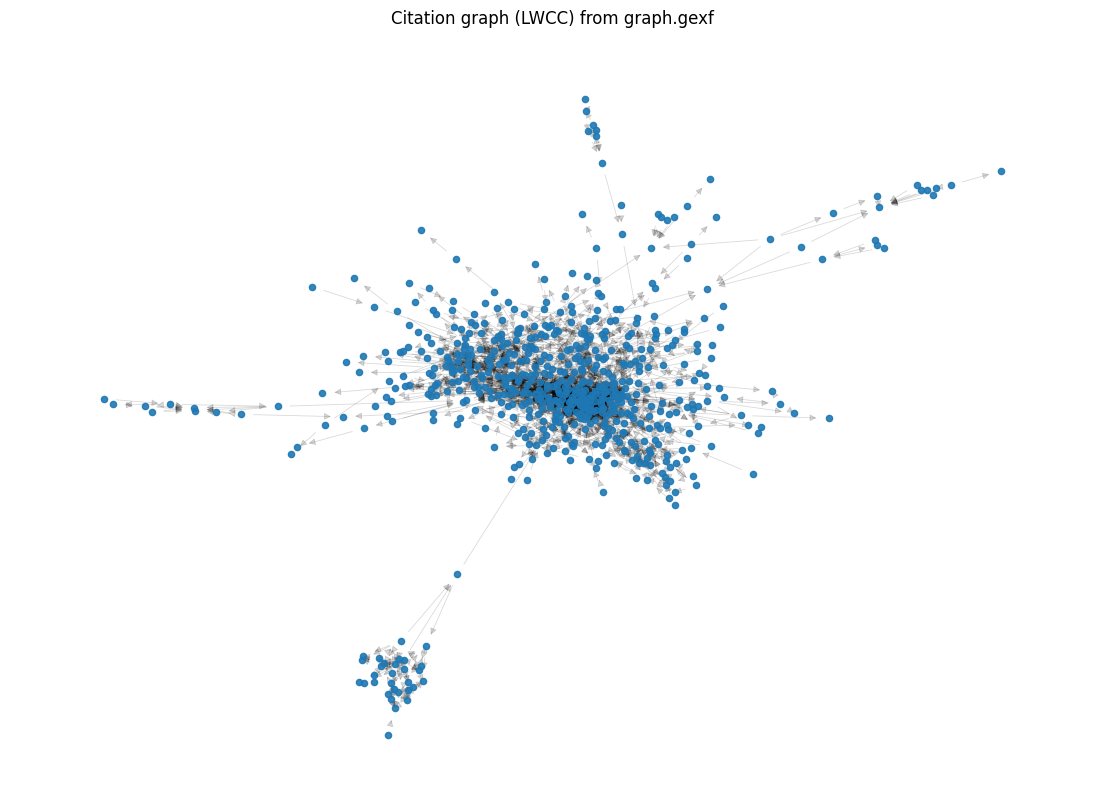

In [11]:
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt

GEXF_PATH = Path(CFG.artifacts_dir) / "graph.gexf"
Gg = nx.read_gexf(GEXF_PATH)

print("Loaded GEXF:", GEXF_PATH)
print("nodes:", Gg.number_of_nodes(), "edges:", Gg.number_of_edges())

# ---- recommended: draw largest weakly connected component (LWCC) ----
wccs = list(nx.weakly_connected_components(Gg))
lwcc_nodes = max(wccs, key=len)
H = Gg.subgraph(lwcc_nodes).copy()

print("LWCC nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

# Layout (spring layout; for big graphs, increase iterations only if needed)
pos = nx.spring_layout(H, seed=42, k=None)

plt.figure(figsize=(14, 10))
nx.draw_networkx_edges(H, pos, alpha=0.15, width=0.6)
nx.draw_networkx_nodes(H, pos, node_size=20, alpha=0.9)
plt.title("Citation graph (LWCC) from graph.gexf")
plt.axis("off")
plt.show()


In [14]:
from pyvis.network import Network
from pathlib import Path
import pandas as pd
import networkx as nx

# ----------------
# Load graph + node table
# ----------------
nodes_df = nodes_viz_df.copy()      # Section 9 で作ったもの
edges_df = edges_viz_df.copy()
G_py = G.copy()                     # networkx graph (Section 5)

# ----------------
# Build PyVis network
# ----------------
net = Network(
    height="800px",
    width="100%",
    bgcolor="#ffffff",
    font_color="#333333",
    directed=True,
    notebook=True,
    cdn_resources="in_line",   # ← Notebook表示では必須
)

# Interaction settings (重要)
net.set_options("""
{
  "interaction": {
    "hover": true,
    "tooltipDelay": 200,
    "hideEdgesOnDrag": true,
    "hideEdgesOnZoom": true
  },
  "nodes": {
    "shape": "dot",
    "scaling": {
      "min": 5,
      "max": 30
    },
    "font": {
      "size": 0
    }
  },
  "physics": {
    "enabled": true,
    "solver": "forceAtlas2Based",
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 120,
      "springConstant": 0.08
    },
    "minVelocity": 0.75
  }
}
""")

# ----------------
# Add nodes
# ----------------
for _, r in nodes_df.iterrows():
    node_id = r["paper_uid"]

    # hover / click で表示する詳細（HTML可）
    title_html = f"""
    {r.get('label','')}
    Year: {r.get('publication_year','')}
    Community: {r.get('community_id','')}
    PageRank: {r.get('pagerank',0):.4f}
    In-degree: {r.get('in_degree',0)}
    RQ score: {r.get('rq_score','')}
    """

    net.add_node(
        node_id,
        label="",              # ← 常時ラベルは出さない
        title=title_html,      # ← hover / click で表示
        value=float(r.get("pagerank", 0)) * 5000 + 5,  # ノードサイズ
        group=int(r.get("community_id", -1)),
    )

# ----------------
# Add edges
# ----------------
for _, r in edges_df.iterrows():
    net.add_edge(
        r["Source"],
        r["Target"],
        value=r.get("Weight", 1.0),
    )

# ----------------
# Save + display
# ----------------
out_html = Path(CFG.artifacts_dir) / "graph_pyvis_inline.html"
net.write_html(str(out_html)) 

from IPython.display import HTML, display
display(HTML(out_html.read_text(encoding="utf-8")))

print("Saved:", out_html)


Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/graph_pyvis_inline.html


In [13]:
# ============================================================
# 10. RQ × Community "Reading Map" + Gap Signals (auto)
# ============================================================
#
# Goal
# ----------------
# Given:
# - node table with RQ-alignment + graph metrics + community labels
# This cell produces, for each Research Question (RQ):
# - Which communities are most relevant (RQ × community scoring)
# - A structured reading list per community:
#     A) STRUCTURAL CORE (PageRank / in-degree leaders)
#     B) RQ-FOCUSED (highest rq_score within the community)
#     C) BRIDGES (boundary / cross-community connectors)
# - Simple "gap" signals per community (where RQ is under-connected)
#
# Inputs (expected)
# ----------------
# - nodes_with_metrics_df : DataFrame from Section 7
#       must include: paper_uid, title, rq_score (or rq_score_<rq_id>), pagerank, in_degree,
#                     out_degree, community_id, community_size, publication_year, cited_by_count
# - edges_graph_df : DataFrame from Section 4
#       must include: source_uid, target_uid, (optional) target_is_external
# - (optional) rq_df : DataFrame of RQs (e.g., from Notion) with columns:
#       rq_id, rq_en, priority
#
# Outputs
# ----------------
# - rq_community_scores.csv
# - rq_reading_map.json
# - rq_reading_map.md   (human-readable)
# - rq_gap_signals.csv
#

from __future__ import annotations

from pathlib import Path
import json
import math
import pandas as pd
import numpy as np

# ----------------
# Configuration
# ----------------
TOP_COMMUNITIES_PER_RQ = 5

TOP_STRUCTURAL_CORE = 5   # per (RQ, community)
TOP_RQ_FOCUSED = 8
TOP_BRIDGES = 5

MIN_COMMUNITY_SIZE = 10      # ignore tiny communities for "focus" scoring
MIN_RQ_SCORE = 0.005         # minimum rq_score to treat as meaningful
RECENCY_YEAR = 2015          # used in gap heuristics
GAP_CORE_PAGERANK_Q = 0.90   # "core nodes" threshold within a community (top 10% by pagerank)

ART_DIR = Path(CFG.artifacts_dir)
OUT_COMM_SCORES = ART_DIR / "rq_community_scores.csv"
OUT_GAP_SIGNALS = ART_DIR / "rq_gap_signals.csv"
OUT_MAP_JSON = ART_DIR / "rq_reading_map.json"
OUT_MAP_MD = ART_DIR / "rq_reading_map.md"

# ----------------
# Helpers
# ----------------
def safe_log1p(x: float) -> float:
    try:
        return float(np.log1p(max(0.0, float(x))))
    except Exception:
        return 0.0

def clip01(x: float) -> float:
    try:
        return float(np.clip(float(x), 0.0, 1.0))
    except Exception:
        return 0.0

def ensure_cols(df: pd.DataFrame, cols: list[str], name: str) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing required columns: {missing}")

def pick_rq_columns(nodes_df: pd.DataFrame) -> dict[str, str]:
    """
    Decide which RQ score columns to use.
    - If rq_df exists and nodes have rq_score_<rq_id> columns, use those.
    - Else fall back to a single global 'rq_score' for all RQs.
    Returns: {rq_key -> rq_score_column}
    """
    if "rq_df" in globals():
        if "rq_id" in rq_df.columns:
            mapping = {}
            for rid in rq_df["rq_id"].astype(str).tolist():
                col = f"rq_score_{rid}"
                if col in nodes_df.columns:
                    mapping[rid] = col
            if mapping:
                return mapping

    # fallback: single score
    if "rq_score" in nodes_df.columns:
        return {"GLOBAL": "rq_score"}

    raise ValueError("No RQ score column found (expected 'rq_score' or 'rq_score_<rq_id>').")

def build_bridge_scores(edges_df: pd.DataFrame, nodes_df: pd.DataFrame) -> pd.Series:
    """
    Bridge score: number of unique cross-community links touching each node.
    For each node u, count edges (u->v or v->u) where community(u) != community(v).
    """
    ensure_cols(edges_df, ["source_uid", "target_uid"], "edges_graph_df")
    ensure_cols(nodes_df, ["paper_uid", "community_id"], "nodes_with_metrics_df")

    comm = nodes_df.set_index("paper_uid")["community_id"].to_dict()

    e = edges_df[["source_uid", "target_uid"]].copy()
    e["c_s"] = e["source_uid"].map(comm)
    e["c_t"] = e["target_uid"].map(comm)

    # keep only edges where both endpoints are internal nodes and communities differ
    e = e.dropna(subset=["c_s", "c_t"])
    e = e[e["c_s"].astype(int) != e["c_t"].astype(int)].copy()

    # count cross-community touches per node
    src_counts = e.groupby("source_uid")["target_uid"].nunique()
    tgt_counts = e.groupby("target_uid")["source_uid"].nunique()

    bridge = src_counts.add(tgt_counts, fill_value=0).astype(int)
    return bridge

def to_record(df: pd.DataFrame, cols: list[str]) -> list[dict]:
    cols = [c for c in cols if c in df.columns]
    return df[cols].to_dict(orient="records")

# ----------------
# Validate inputs
# ----------------
ensure_cols(
    nodes_with_metrics_df,
    ["paper_uid", "title", "community_id", "community_size", "pagerank", "in_degree", "out_degree"],
    "nodes_with_metrics_df",
)
ensure_cols(edges_graph_df, ["source_uid", "target_uid"], "edges_graph_df")

nodes = nodes_with_metrics_df.copy()

# Filter out "noise/unassigned" for community focus scoring, but we keep -1 nodes for lists if needed
nodes["community_id"] = nodes["community_id"].fillna(-1).astype(int)
nodes["community_size"] = nodes["community_size"].fillna(0).astype(int)

# ----------------
# Prepare RQ list
# ----------------
rq_col_map = pick_rq_columns(nodes)

if "rq_df" in globals() and "rq_id" in rq_df.columns:
    rq_list = rq_df.copy()
    rq_list["rq_id"] = rq_list["rq_id"].astype(str)
    if "rq_en" not in rq_list.columns:
        rq_list["rq_en"] = rq_list["rq_id"]
else:
    rq_list = pd.DataFrame([{"rq_id": k, "rq_en": "GLOBAL (single rq_score)", "priority": ""} for k in rq_col_map.keys()])

print("RQ keys:", list(rq_col_map.keys()))
print("RQ score mapping:", rq_col_map)

# ----------------
# Precompute bridge scores (graph structure)
# ----------------
bridge_score = build_bridge_scores(edges_graph_df, nodes)
nodes["bridge_score"] = nodes["paper_uid"].map(bridge_score).fillna(0).astype(int)

log_event("rq_reading_map_bridge_score", "ok", {
    "bridge_nonzero": int((nodes["bridge_score"] > 0).sum()),
})

# ----------------
# 1) Score communities per RQ
# ----------------
community_scores_rows = []

# precompute community-level pagerank quantiles for "core nodes"
pagerank_q = (
    nodes[nodes["community_id"] != -1]
    .groupby("community_id")["pagerank"]
    .quantile(GAP_CORE_PAGERANK_Q)
    .to_dict()
)

for _, rq in rq_list.iterrows():
    rq_id = str(rq["rq_id"])
    rq_name = str(rq.get("rq_en", rq_id))
    rq_score_col = rq_col_map.get(rq_id, rq_col_map.get("GLOBAL", "rq_score"))

    tmp = nodes.copy()
    tmp["_rq"] = tmp[rq_score_col].fillna(0.0).astype(float)

    # focus on assigned communities; ignore -1 for scoring
    tmp = tmp[(tmp["community_id"] != -1) & (tmp["community_size"] >= MIN_COMMUNITY_SIZE)].copy()

    if tmp.empty:
        continue

    # community aggregates
    g = tmp.groupby("community_id").agg(
        community_size=("paper_uid", "count"),
        avg_rq=(" _rq".replace(" ", ""), "mean") if False else ("_rq", "mean"),
        p90_rq=("_rq", lambda s: float(np.quantile(s, 0.90))),
        n_rq_hits=("_rq", lambda s: int((s >= MIN_RQ_SCORE).sum())),
        avg_pagerank=("pagerank", "mean"),
        avg_in_degree=("in_degree", "mean"),
    ).reset_index()

    # "relevance" heuristic:
    # - more rq hits + higher avg rq + some structural weight
    g["rq_density"] = g["n_rq_hits"] / g["community_size"].replace(0, np.nan)
    g["rq_density"] = g["rq_density"].fillna(0.0)

    g["score"] = (
        0.45 * clip01(g["avg_rq"] * 40) +
        0.30 * clip01(g["rq_density"] * 5) +
        0.15 * clip01(np.log1p(g["avg_in_degree"]) / 5) +
        0.10 * clip01(np.log1p(g["avg_pagerank"]) * 10)
    )

    g["rq_id"] = rq_id
    g["rq_en"] = rq_name
    g["rq_score_col"] = rq_score_col

    # sort
    g = g.sort_values("score", ascending=False).reset_index(drop=True)
    g["rank"] = (g.index + 1).astype(int)

    community_scores_rows.append(g)

rq_community_scores_df = pd.concat(community_scores_rows, ignore_index=True) if community_scores_rows else pd.DataFrame()

rq_community_scores_df.to_csv(OUT_COMM_SCORES, index=False)
print("Saved:", OUT_COMM_SCORES)
display(rq_community_scores_df.head(20))

log_event("rq_community_scores", "ok", {
    "rows": int(rq_community_scores_df.shape[0]),
})

# ----------------
# 2) Build per-RQ reading map
# ----------------
reading_map = {}

def build_lists_for_rq_comm(rq_score_col: str, comm_id: int) -> dict:
    dfc = nodes[nodes["community_id"] == comm_id].copy()
    dfc["_rq"] = dfc[rq_score_col].fillna(0.0).astype(float)

    # A) structural core
    core = (
        dfc.sort_values(["pagerank", "in_degree"], ascending=[False, False])
        .head(TOP_STRUCTURAL_CORE)
        .copy()
    )

    # B) rq-focused
    rq_focused = (
        dfc[dfc["_rq"] >= MIN_RQ_SCORE]
        .sort_values(["_rq", "publication_year", "pagerank"], ascending=[False, False, False])
        .head(TOP_RQ_FOCUSED)
        .copy()
    )

    # C) bridges (cross-community connectors)
    bridges = (
        dfc.sort_values(["bridge_score", "out_degree", "pagerank"], ascending=[False, False, False])
        .head(TOP_BRIDGES)
        .copy()
    )

    cols = [
        "paper_uid", "title", "publication_year", "venue",
        "pagerank", "in_degree", "out_degree", "bridge_score",
        "rq_score", "priority_score", "cited_by_count",
        "openalex_id", "doi_norm", "notion_page_url",
        "community_id", "community_size",
    ]

    # replace rq_score column name in outputs
    if rq_score_col != "rq_score" and rq_score_col in dfc.columns:
        # output as rq_score (uniform)
        for d in (core, rq_focused, bridges):
            d["rq_score"] = d[rq_score_col].astype(float)

    return {
        "structural_core": to_record(core, cols),
        "rq_focused": to_record(rq_focused, cols),
        "bridges": to_record(bridges, cols),
    }

# ----------------
# 3) Gap signals (simple heuristics)
# ----------------
gap_rows = []

def gap_signals_for_rq_comm(rq_score_col: str, comm_id: int) -> dict:
    dfc = nodes[nodes["community_id"] == comm_id].copy()
    dfc["_rq"] = dfc[rq_score_col].fillna(0.0).astype(float)

    if dfc.empty:
        return {}

    # Core-under-connected: high-PageRank nodes but low RQ score
    q = pagerank_q.get(comm_id, None)
    if q is None:
        core_mask = dfc["pagerank"] >= dfc["pagerank"].quantile(GAP_CORE_PAGERANK_Q)
    else:
        core_mask = dfc["pagerank"] >= float(q)

    core_nodes = dfc[core_mask].copy()
    core_low_rq = core_nodes[core_nodes["_rq"] < MIN_RQ_SCORE]
    core_low_rq_rate = (len(core_low_rq) / max(1, len(core_nodes)))

    # High RQ but low structural integration (low in-degree within graph)
    rq_high = dfc[dfc["_rq"] >= MIN_RQ_SCORE].copy()
    rq_high_low_in = rq_high[rq_high["in_degree"] <= 1]
    rq_high_low_in_rate = (len(rq_high_low_in) / max(1, len(rq_high)))

    # Recency gap: many high-RQ recent nodes but low pagerank (not integrated yet)
    recent = dfc[dfc.get("publication_year", 0).fillna(0) >= RECENCY_YEAR].copy()
    recent["_rq"] = recent["_rq"].fillna(0.0)
    recent_high_rq = recent[recent["_rq"] >= MIN_RQ_SCORE]
    recent_high_rq_low_pr = recent_high_rq[recent_high_rq["pagerank"] <= recent_high_rq["pagerank"].median()]  # heuristic
    recent_gap = len(recent_high_rq_low_pr)

    # Compose signal
    return {
        "rq_core_under_connected_rate": float(core_low_rq_rate),
        "rq_high_but_low_in_degree_rate": float(rq_high_low_in_rate),
        "recent_high_rq_low_integration_count": int(recent_gap),
        "n_core_nodes": int(len(core_nodes)),
        "n_rq_high_nodes": int(len(rq_high)),
        "n_recent_nodes": int(len(recent)),
    }

# build reading map per RQ
for _, rq in rq_list.iterrows():
    rq_id = str(rq["rq_id"])
    rq_name = str(rq.get("rq_en", rq_id))
    rq_score_col = rq_col_map.get(rq_id, rq_col_map.get("GLOBAL", "rq_score"))

    # pick top communities
    comms = []
    if not rq_community_scores_df.empty:
        comms = (
            rq_community_scores_df[rq_community_scores_df["rq_id"] == rq_id]
            .sort_values("score", ascending=False)
            .head(TOP_COMMUNITIES_PER_RQ)["community_id"]
            .astype(int)
            .tolist()
        )

    # if no scoring (e.g., GLOBAL and empty), fallback to biggest communities
    if not comms:
        comms = (
            nodes[(nodes["community_id"] != -1) & (nodes["community_size"] >= MIN_COMMUNITY_SIZE)]
            .groupby("community_id")["paper_uid"].count()
            .sort_values(ascending=False)
            .head(TOP_COMMUNITIES_PER_RQ)
            .index.astype(int)
            .tolist()
        )

    reading_map[rq_id] = {
        "rq_en": rq_name,
        "priority": str(rq.get("priority", "")),
        "rq_score_col": rq_score_col,
        "top_communities": [],
    }

    for comm_id in comms:
        comm_size = int(nodes.loc[nodes["community_id"] == comm_id, "community_size"].max() or 0)
        lists = build_lists_for_rq_comm(rq_score_col, comm_id)

        gaps = gap_signals_for_rq_comm(rq_score_col, comm_id)
        gap_rows.append({
            "rq_id": rq_id,
            "rq_en": rq_name,
            "community_id": int(comm_id),
            "community_size": int(comm_size),
            **gaps,
        })

        reading_map[rq_id]["top_communities"].append({
            "community_id": int(comm_id),
            "community_size": int(comm_size),
            "reading_lists": lists,
            "gap_signals": gaps,
        })

# Save JSON
with open(OUT_MAP_JSON, "w", encoding="utf-8") as f:
    json.dump(reading_map, f, ensure_ascii=False, indent=2)

print("Saved:", OUT_MAP_JSON)
log_event("rq_reading_map_json", "ok", {"rqs": int(len(reading_map))})

# Save gap signals table
rq_gap_signals_df = pd.DataFrame(gap_rows)
rq_gap_signals_df.to_csv(OUT_GAP_SIGNALS, index=False)
print("Saved:", OUT_GAP_SIGNALS)
display(rq_gap_signals_df.head(20))

log_event("rq_gap_signals", "ok", {"rows": int(rq_gap_signals_df.shape[0])})

# ----------------
# Human-readable Markdown summary
# ----------------
md_lines = []
md_lines.append(f"# RQ × Community Reading Map\n")
md_lines.append(f"- Generated from: {CFG.run_id}\n")
md_lines.append(f"- Artifacts dir: {ART_DIR}\n")

for rq_id, obj in reading_map.items():
    md_lines.append(f"\n## RQ: {rq_id}\n")
    md_lines.append(f"- {obj.get('rq_en','')}\n")
    if obj.get("priority"):
        md_lines.append(f"- Priority: {obj['priority']}\n")

    for comm in obj["top_communities"]:
        cid = comm["community_id"]
        csize = comm["community_size"]
        md_lines.append(f"\n### Community {cid} (size={csize})\n")

        gaps = comm.get("gap_signals", {})
        if gaps:
            md_lines.append(
                f"- Gap signals: core_under_connected={gaps.get('rq_core_under_connected_rate',0):.2f}, "
                f"rq_high_low_in={gaps.get('rq_high_but_low_in_degree_rate',0):.2f}, "
                f"recent_high_rq_low_integration={gaps.get('recent_high_rq_low_integration_count',0)}\n"
            )

        def _fmt_list(title: str, items: list[dict], k: int = 5):
            md_lines.append(f"\n**{title}**\n")
            if not items:
                md_lines.append("- (none)\n")
                return
            for it in items[:k]:
                y = it.get("publication_year", "")
                pr = it.get("pagerank", 0.0)
                rqv = it.get("rq_score", 0.0)
                md_lines.append(f"- {it.get('title','(no title)')} ({y}) | PR={pr:.4f} | RQ={rqv:.3f}\n")

        lists = comm["reading_lists"]
        _fmt_list("A) Structural core (start here)", lists.get("structural_core", []), k=TOP_STRUCTURAL_CORE)
        _fmt_list("B) RQ-focused (direct evidence)", lists.get("rq_focused", []), k=TOP_RQ_FOCUSED)
        _fmt_list("C) Bridges (boundary / connectors)", lists.get("bridges", []), k=TOP_BRIDGES)

md_text = "".join(md_lines)
with open(OUT_MAP_MD, "w", encoding="utf-8") as f:
    f.write(md_text)

print("Saved:", OUT_MAP_MD)
log_event("rq_reading_map_md", "ok", {"path": str(OUT_MAP_MD)})

# Preview
print("\n--- Preview (first 80 lines) ---")
for line in md_lines[:80]:
    print(line, end="")


RQ keys: ['GLOBAL']
RQ score mapping: {'GLOBAL': 'rq_score'}
Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/rq_community_scores.csv


,community_id,community_size,avg_rq,p90_rq,n_rq_hits,avg_pagerank,avg_in_degree,rq_density,score,rq_id,rq_en,rq_score_col,rank
0,0,176,0.016308,0.032692,136,0.001196,4.318182,0.772727,0.0,GLOBAL,GLOBAL (single rq_score),rq_score,1
1,1,124,0.014423,0.030769,96,0.001116,4.354839,0.774194,0.0,GLOBAL,GLOBAL (single rq_score),rq_score,2
2,2,103,0.010642,0.023077,65,0.001612,4.533981,0.631068,0.0,GLOBAL,GLOBAL (single rq_score),rq_score,3
3,3,67,0.014638,0.030769,53,0.001951,9.671642,0.791045,0.0,GLOBAL,GLOBAL (single rq_score),rq_score,4
4,4,41,0.011069,0.026923,26,0.000878,1.390244,0.634146,0.0,GLOBAL,GLOBAL (single rq_score),rq_score,5
5,5,31,0.008561,0.015385,18,0.001350,2.741935,0.580645,0.0,GLOBAL,GLOBAL (single rq_score),rq_score,6
6,6,31,0.006948,0.015385,11,0.001045,2.741935,0.354839,0.0,GLOBAL,GLOBAL (single rq_score),rq_score,7
7,7,11,0.004545,0.007692,2,0.000964,1.727273,0.181818,0.0,GLOBAL,GLOBAL (single rq_score),rq_score,8


Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/rq_reading_map.json
Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/rq_gap_signals.csv


,rq_id,rq_en,community_id,community_size,rq_core_under_connected_rate,rq_high_but_low_in_degree_rate,recent_high_rq_low_integration_count,n_core_nodes,n_rq_high_nodes,n_recent_nodes
0,GLOBAL,GLOBAL (single rq_score),0,176,0.222222,0.397059,15,18,136,33
1,GLOBAL,GLOBAL (single rq_score),1,124,0.307692,0.375000,4,13,96,7
2,GLOBAL,GLOBAL (single rq_score),2,103,0.363636,0.353846,3,11,65,6
3,GLOBAL,GLOBAL (single rq_score),3,67,0.142857,0.245283,1,7,53,1
4,GLOBAL,GLOBAL (single rq_score),4,41,0.200000,0.653846,7,5,26,19


Saved: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608/rq_reading_map.md

--- Preview (first 80 lines) ---
# RQ × Community Reading Map
- Generated from: 20260114_094608
- Artifacts dir: /Users/yuetoya/Desktop/researchOS100-private/notebooks/artifacts/day21_paper_graph_20260114_094608

## RQ: GLOBAL
- GLOBAL (single rq_score)

### Community 0 (size=176)
- Gap signals: core_under_connected=0.22, rq_high_low_in=0.40, recent_high_rq_low_integration=15

**A) Structural core (start here)**
- Syndicated investments by venture capital firms: A networking perspective (1987.0) | PR=0.0165 | RQ=0.019
- The structure of the investment networks of venture capital firms (1988.0) | PR=0.0149 | RQ=0.019
- Route 128: The development of a regional high technology economy (1983.0) | PR=0.0074 | RQ=0.008
- Geographic Localization of Knowledge Spillovers as Evidenced by Patent Citations (1993.0) | PR=0.0074 | RQ=0.000
- The Syndication of Venture Capital 